# final_chip.ipynb

This notebook builds the final 4 × 9 chip array from the organized TS01–TS07 master cell.

Run order:
1. Run the imports/settings/base-geometry cell.
2. Run the TS01–TS07 + organized master-generator cell.
3. Set the two designed 50/50 lengths and beat lengths in the final-chip cell.
4. Run the final-chip cell to write the GDS and CSV summary.

Rows:
- Row 1: width 300 nm, gap 250 nm, fine sweep around L50.
- Row 2: width 300 nm, gap 250 nm, beat sweep from L50 to L50 + 1.3 Lπ.
- Row 3: width 500 nm, gap 150 nm, fine sweep around L50.
- Row 4: width 500 nm, gap 150 nm, beat sweep from L50 to L50 + 1.3 Lπ.


In [1]:
# ============================================================
# final_chip.ipynb -- imports, folders, layers, settings, and base geometry
# ============================================================
# Run this cell first.

from pathlib import Path
import numpy as np
import pandas as pd
import gdsfactory as gf
import uuid

# Clear gdsfactory cache when rerunning notebook cells
gf.clear_cache()

# ------------------------------------------------------------
# Output folders
# ------------------------------------------------------------
GDS_DIR = Path("gds")
GDS_DIR.mkdir(exist_ok=True)

DOE_GDS_DIR = GDS_DIR / "doe"
DOE_GDS_DIR.mkdir(exist_ok=True)

print(f"GDS folder:     {GDS_DIR.resolve()}")
print(f"DOE GDS folder: {DOE_GDS_DIR.resolve()}")

# ------------------------------------------------------------
# Layers
# ------------------------------------------------------------
WG_LAYER = (1, 0)

# Visible polygon text layer:
# This is actual GDS geometry and can be hidden in KLayout by hiding layer 10/0.
TEXT_LAYER = (10, 0)

# True GDS label layer:
# This is metadata label/text and can be hidden separately in KLayout by hiding layer 11/0.
LABEL_LAYER = (11, 0)

# ------------------------------------------------------------
# Text / label sizes
# ------------------------------------------------------------
# These sizes are for visible polygon text in the GDS.
# True GDS labels do not have a fixed physical size like polygon text.
# Their displayed size is controlled by the viewer, for example KLayout.
PORT_TEXT_SIZE_UM = 5.0
GC_TEXT_SIZE_UM = 5.0
DOE_TEXT_SIZE_UM = 10.0

# ------------------------------------------------------------
# Beam-splitter design parameters
# ------------------------------------------------------------
bs_wg_width_um = 0.300
bs_gap_um = 0.250
bs_coupling_length_um = 1.772

# BS external port pitch:
# port 1 and 2 on left side are separated by this pitch.
# port 3 and 4 on right side are also separated by this pitch.
bs_port_pitch_um = 4.0

# S-bend inside the BS
bs_sbend_x_um = 25.0

# Short straight sections before and after internal BS S-bends
bs_input_straight_um = 5.0
bs_output_straight_um = 5.0

# ------------------------------------------------------------
# Fiber array and grating coupler parameters
# ------------------------------------------------------------
fiber_array_pitch_um = 127.0
fiber_pitch_um = fiber_array_pitch_um

# GCs are arranged vertically and face left-to-right.
# Their waveguide output ports point in +x direction.
gc_output_width_um = 0.500
gc_wavelength_um = 1.550

# Taper from GC width to BS waveguide width
taper_length_um = 50.0

# ------------------------------------------------------------
# DOE / TS routing parameters
# ------------------------------------------------------------
# Middle GC pitch 127 um -> BS pitch 4 um
input_fanout_length_um = 350.0

# Output ports 3 and 4 first go right, make 180-degree bends,
# then return left to the outer GCs.
output_straight_before_uturn_um = 30.0
output_uturn_radius_um = 45.0

# Extra horizontal return length after the 180-degree bend.
# Increase this if you want a smoother/longer S-bend to the outer GCs.
output_return_extra_x_um = 250.0

# ------------------------------------------------------------
# Sampling resolution
# ------------------------------------------------------------
num_sbend_points = 151
num_straight_points = 31
num_bend_points = 151

# ------------------------------------------------------------
# BS port convention
# ------------------------------------------------------------
# port 1 = left-bottom
# port 2 = left-top
# port 3 = right-bottom, through port of port 1
# port 4 = right-top
#
# So:
#   1 -> 3 is bottom through path
#   2 -> 4 is top through path

print("Initial settings:")
print(f"  BS waveguide width     = {bs_wg_width_um:.3f} um")
print(f"  BS gap                 = {bs_gap_um:.3f} um")
print(f"  BS coupling length     = {bs_coupling_length_um:.3f} um")
print(f"  BS port pitch          = {bs_port_pitch_um:.3f} um")
print(f"  BS internal S-bend x   = {bs_sbend_x_um:.3f} um")
print(f"  Fiber-array pitch      = {fiber_array_pitch_um:.3f} um")
print(f"  GC output width        = {gc_output_width_um:.3f} um")
print(f"  Taper length           = {taper_length_um:.3f} um")
print(f"  Output U-turn radius   = {output_uturn_radius_um:.3f} um")
print(f"  Port text size         = {PORT_TEXT_SIZE_UM:.1f} um")
print(f"  GC text size           = {GC_TEXT_SIZE_UM:.1f} um")
print(f"  DOE title text size    = {DOE_TEXT_SIZE_UM:.1f} um")


# ============================================================
# Helper functions
# ============================================================

def unique_cell_name(base_name: str) -> str:
    """Make a unique cell name to avoid duplicate-cell errors in notebooks."""
    tag = uuid.uuid4().hex[:8]
    return f"{base_name}_{tag}"


def get_port_by_name_or_first(component_or_ref, preferred_names=("o1", "opt1")):
    """
    Robustly get a port from different gdsfactory versions.

    Works with dict-like ports, DPorts, and components that support get_ports_list().
    """
    ports = component_or_ref.ports

    # Try preferred names
    for name in preferred_names:
        try:
            return ports[name]
        except Exception:
            pass

    # Try integer indexing
    try:
        return ports[0]
    except Exception:
        pass

    # Try get_ports_list()
    try:
        plist = component_or_ref.get_ports_list()
        if len(plist) > 0:
            return plist[0]
    except Exception:
        pass

    # Try iteration over ports
    try:
        first = list(ports)[0]

        # Some versions return the port directly
        if hasattr(first, "center") and hasattr(first, "orientation"):
            return first

        # Some versions return the port name
        try:
            return ports[first]
        except Exception:
            pass

    except Exception:
        pass

    raise RuntimeError("Could not extract a port from this component/reference.")


def get_named_port(component_or_ref, port_name: str):
    """Get a port by exact name."""
    ports = component_or_ref.ports

    try:
        return ports[port_name]
    except Exception:
        pass

    try:
        for p in ports:
            if str(p.name) == str(port_name):
                return p
    except Exception:
        pass

    try:
        return component_or_ref.get_ports_dict()[port_name]
    except Exception:
        pass

    raise KeyError(f"Port {port_name!r} was not found.")


def get_port_center_xy(port) -> tuple[float, float]:
    """Return port center as float x, y."""
    try:
        center = port.center
        return float(center[0]), float(center[1])
    except Exception:
        pass

    try:
        center = port.dcenter
        return float(center[0]), float(center[1])
    except Exception:
        pass

    raise RuntimeError("Could not read port center.")


def smoothstep(t: np.ndarray) -> np.ndarray:
    """Cubic smoothstep with zero slope at both ends."""
    return 3 * t**2 - 2 * t**3


def make_straight_centerline(
    x0: float,
    x1: float,
    y: float,
    npoints: int = 31,
) -> tuple[np.ndarray, np.ndarray]:
    x = np.linspace(x0, x1, npoints)
    yarr = np.full_like(x, y)
    return x, yarr


def make_sbend_centerline(
    x0: float,
    x1: float,
    y0: float,
    y1: float,
    npoints: int = 151,
) -> tuple[np.ndarray, np.ndarray]:
    t = np.linspace(0, 1, npoints)
    x = x0 + (x1 - x0) * t
    y = y0 + (y1 - y0) * smoothstep(t)
    return x, y


def make_180_bend_centerline(
    x_start: float,
    y_start: float,
    radius: float,
    direction: str = "up",
    npoints: int = 151,
) -> tuple[np.ndarray, np.ndarray]:
    """
    180-degree circular bend.

    Input tangent is +x.
    Output tangent is -x.

    direction = "up":
        end point is at y_start + 2R.

    direction = "down":
        end point is at y_start - 2R.
    """
    if direction == "up":
        theta = np.linspace(-np.pi / 2, +np.pi / 2, npoints)
        x_center = x_start
        y_center = y_start + radius

    elif direction == "down":
        theta = np.linspace(+np.pi / 2, -np.pi / 2, npoints)
        x_center = x_start
        y_center = y_start - radius

    else:
        raise ValueError("direction must be 'up' or 'down'.")

    x = x_center + radius * np.cos(theta)
    y = y_center + radius * np.sin(theta)

    return x, y


def centerline_to_polygon(
    x: np.ndarray,
    y: np.ndarray,
    width: float,
) -> list[tuple[float, float]]:
    """Convert a sampled centerline to a waveguide polygon."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if len(x) != len(y):
        raise ValueError("x and y must have the same length.")

    if len(x) < 2:
        raise ValueError("Centerline must contain at least two points.")

    dx = np.gradient(x)
    dy = np.gradient(y)

    ds = np.sqrt(dx**2 + dy**2)

    if np.any(ds == 0):
        raise ValueError("Centerline contains repeated points.")

    nx = -dy / ds
    ny = dx / ds

    half_width = width / 2

    x_upper = x + half_width * nx
    y_upper = y + half_width * ny

    x_lower = x - half_width * nx
    y_lower = y - half_width * ny

    polygon_x = np.concatenate([x_upper, x_lower[::-1]])
    polygon_y = np.concatenate([y_upper, y_lower[::-1]])

    return list(zip(polygon_x, polygon_y))


def add_centerline_waveguide(
    c: gf.Component,
    x: np.ndarray,
    y: np.ndarray,
    width: float,
    layer: tuple[int, int] = WG_LAYER,
):
    polygon = centerline_to_polygon(x, y, width)
    c.add_polygon(polygon, layer=layer)


def add_taper_polygon(
    c: gf.Component,
    x0: float,
    x1: float,
    y: float,
    width0: float,
    width1: float,
    layer: tuple[int, int] = WG_LAYER,
):
    """Horizontal linear taper polygon."""
    pts = [
        (x0, y - width0 / 2),
        (x0, y + width0 / 2),
        (x1, y + width1 / 2),
        (x1, y - width1 / 2),
    ]
    c.add_polygon(pts, layer=layer)


def add_visible_text(
    c: gf.Component,
    text: str,
    position: tuple[float, float],
    size: float = GC_TEXT_SIZE_UM,
    text_layer: tuple[int, int] = TEXT_LAYER,
    label_layer: tuple[int, int] = LABEL_LAYER,
    add_gds_label: bool = True,
):
    """
    Add visible polygon text and, optionally, a separate GDS label.

    Visible polygon text:
        Goes to TEXT_LAYER, default (10, 0).
        This appears as actual geometry in KLayout.

    GDS label:
        Goes to LABEL_LAYER, default (11, 0).
        This is separate from the polygon text so you can hide/show it independently.
    """
    txt = gf.components.text(
        text=text,
        size=size,
        layer=text_layer,
    )
    r = c << txt
    r.move(position)

    if add_gds_label:
        c.add_label(
            text=text,
            position=position,
            layer=label_layer,
        )


def make_gc_1550_l2r(
    name: str = "gc_1550_l2r",
    wg_layer: tuple[int, int] = WG_LAYER,
    output_width: float = gc_output_width_um,
) -> gf.Component:
    """
    Grating coupler with one optical port called o1 pointing +x.

    This version first tries the built-in elliptical TE grating.
    If that fails, it creates a simple placeholder GC.
    """
    c = gf.Component(unique_cell_name(name))

    try:
        xs = gf.cross_section.strip(
            width=output_width,
            layer=wg_layer,
        )

        base = gf.components.grating_coupler_elliptical_te(
            cross_section=xs,
            wavelength=1.55,
        )

        r = c << base

        p = get_port_by_name_or_first(r)

        # Most gdsfactory grating couplers have the waveguide port facing west.
        # If so, rotate the reference so the final port faces east, i.e. +x.
        if int(p.orientation) % 360 == 180:
            r.rotate(180)

        # Re-read after rotation
        p = get_port_by_name_or_first(r)

        c.add_port(
            name="o1",
            port=p,
        )

    except Exception as e:
        print("Using fallback placeholder grating coupler.")
        print(f"Reason: {e}")

        grating_width = 12.0
        taper_length_fallback = 20.0
        n_teeth = 12
        tooth_pitch = 0.65
        tooth_width = 0.30

        x0 = 0.0
        x1 = taper_length_fallback

        c.add_polygon(
            [
                (x0, -grating_width / 2),
                (x0, +grating_width / 2),
                (x1, +output_width / 2),
                (x1, -output_width / 2),
            ],
            layer=wg_layer,
        )

        for i in range(n_teeth):
            xa = x0 - i * tooth_pitch
            xb = xa - tooth_width

            c.add_polygon(
                [
                    (xa, -grating_width / 2),
                    (xa, +grating_width / 2),
                    (xb, +grating_width / 2),
                    (xb, -grating_width / 2),
                ],
                layer=wg_layer,
            )

        c.add_port(
            name="o1",
            center=(x1, 0),
            width=output_width,
            orientation=0,
            layer=wg_layer,
        )

    c.info["wavelength_um"] = 1.55
    c.info["output_width_um"] = output_width

    return c


def make_tuned_beam_splitter(
    name: str = "tuned_beam_splitter",
    wg_width: float = bs_wg_width_um,
    gap: float = bs_gap_um,
    coupling_length: float = bs_coupling_length_um,
    external_pitch: float = bs_port_pitch_um,
    sbend_x: float = bs_sbend_x_um,
    input_straight: float = bs_input_straight_um,
    output_straight: float = bs_output_straight_um,
    wg_layer: tuple[int, int] = WG_LAYER,
    text_layer: tuple[int, int] = TEXT_LAYER,
    label_layer: tuple[int, int] = LABEL_LAYER,
    add_labels: bool = True,
) -> gf.Component:
    """
    Symmetric directional-coupler beam splitter.

    Port convention:
        port 1 = left-bottom
        port 2 = left-top
        port 3 = right-bottom
        port 4 = right-top
    """
    c = gf.Component(
        unique_cell_name(
            f"{name}_w{int(wg_width * 1000)}nm_g{int(gap * 1000)}nm_Lc{coupling_length:.3f}um"
        )
    )

    center_sep = wg_width + gap

    y1 = -external_pitch / 2
    y2 = +external_pitch / 2

    yc_lower = -center_sep / 2
    yc_upper = +center_sep / 2

    x0 = 0.0
    x1 = x0 + input_straight
    x2 = x1 + sbend_x
    x3 = x2 + coupling_length
    x4 = x3 + sbend_x
    x5 = x4 + output_straight

    # Lower arm: port 1 -> port 3
    xa, ya = make_straight_centerline(x0, x1, y1, npoints=num_straight_points)
    xb, yb = make_sbend_centerline(x1, x2, y1, yc_lower, npoints=num_sbend_points)
    xc, yc = make_straight_centerline(x2, x3, yc_lower, npoints=num_straight_points)
    xd, yd = make_sbend_centerline(x3, x4, yc_lower, y1, npoints=num_sbend_points)
    xe, ye = make_straight_centerline(x4, x5, y1, npoints=num_straight_points)

    x_lower = np.concatenate([xa, xb[1:], xc[1:], xd[1:], xe[1:]])
    y_lower = np.concatenate([ya, yb[1:], yc[1:], yd[1:], ye[1:]])
    add_centerline_waveguide(c, x_lower, y_lower, width=wg_width, layer=wg_layer)

    # Upper arm: port 2 -> port 4
    xa, ya = make_straight_centerline(x0, x1, y2, npoints=num_straight_points)
    xb, yb = make_sbend_centerline(x1, x2, y2, yc_upper, npoints=num_sbend_points)
    xc, yc = make_straight_centerline(x2, x3, yc_upper, npoints=num_straight_points)
    xd, yd = make_sbend_centerline(x3, x4, yc_upper, y2, npoints=num_sbend_points)
    xe, ye = make_straight_centerline(x4, x5, y2, npoints=num_straight_points)

    x_upper = np.concatenate([xa, xb[1:], xc[1:], xd[1:], xe[1:]])
    y_upper = np.concatenate([ya, yb[1:], yc[1:], yd[1:], ye[1:]])
    add_centerline_waveguide(c, x_upper, y_upper, width=wg_width, layer=wg_layer)

    c.add_port("1", center=(x0, y1), width=wg_width, orientation=180, layer=wg_layer)
    c.add_port("2", center=(x0, y2), width=wg_width, orientation=180, layer=wg_layer)
    c.add_port("3", center=(x5, y1), width=wg_width, orientation=0, layer=wg_layer)
    c.add_port("4", center=(x5, y2), width=wg_width, orientation=0, layer=wg_layer)

    if add_labels:
        add_visible_text(
            c,
            f"BS | W={int(wg_width * 1000)} nm | G={int(gap * 1000)} nm | L={coupling_length:.3f} um",
            position=(x0, y2 + 15.0),
            size=GC_TEXT_SIZE_UM,
            text_layer=text_layer,
            label_layer=label_layer,
            add_gds_label=False,
        )

        c.add_label(
            text=(
                f"BS_w{int(wg_width * 1000)}nm_"
                f"g{int(gap * 1000)}nm_"
                f"Lc{coupling_length:.3f}um"
            ),
            position=(x0, y1 - 15.0),
            layer=label_layer,
        )

    c.info["bs_wg_width_um"] = wg_width
    c.info["bs_gap_um"] = gap
    c.info["bs_coupling_length_um"] = coupling_length
    c.info["bs_external_pitch_um"] = external_pitch
    c.info["bs_total_length_um"] = x5

    return c


print("Initial settings, imports, folders, helper functions, GC, and tuned BS are ready.")

GDS folder:     C:\Users\Amirali\Desktop\Beam_Splitter_Project\layout_creator\gds
DOE GDS folder: C:\Users\Amirali\Desktop\Beam_Splitter_Project\layout_creator\gds\doe
Initial settings:
  BS waveguide width     = 0.300 um
  BS gap                 = 0.250 um
  BS coupling length     = 1.772 um
  BS port pitch          = 4.000 um
  BS internal S-bend x   = 25.000 um
  Fiber-array pitch      = 127.000 um
  GC output width        = 0.500 um
  Taper length           = 50.000 um
  Output U-turn radius   = 45.000 um
  Port text size         = 5.0 um
  GC text size           = 5.0 um
  DOE title text size    = 10.0 um
Initial settings, imports, folders, helper functions, GC, and tuned BS are ready.


In [2]:
# %% [markdown]
# # Single-cell TS01 to TS07 + organized master generator
#
# This cell assumes the base geometry/helper functions already exist:
#
# - make_tuned_beam_splitter
# - make_gc_1550_l2r
# - unique_cell_name
# - get_named_port
# - get_port_center_xy
# - make_straight_centerline
# - make_sbend_centerline
# - make_180_bend_centerline
# - add_centerline_waveguide
# - add_taper_polygon
# - add_visible_text
#
# Global variables assumed:
#
# - WG_LAYER, TEXT_LAYER, LABEL_LAYER
# - DOE_TEXT_SIZE_UM, GC_TEXT_SIZE_UM
# - fiber_array_pitch_um, gc_output_width_um, taper_length_um
# - bs_wg_width_um, bs_gap_um, bs_coupling_length_um
# - bs_port_pitch_um, bs_sbend_x_um
# - bs_input_straight_um, bs_output_straight_um
# - input_fanout_length_um, output_straight_before_uturn_um
# - num_straight_points, num_sbend_points, num_bend_points
# - GDS_DIR, DOE_GDS_DIR

# %%
# ============================================================
# Shared helper functions for TS cells
# ============================================================

def make_arc_centerline(
    x_center: float,
    y_center: float,
    radius: float,
    theta_start: float,
    theta_stop: float,
    npoints: int = 101,
) -> tuple[np.ndarray, np.ndarray]:
    theta = np.linspace(theta_start, theta_stop, npoints)
    x = x_center + radius * np.cos(theta)
    y = y_center + radius * np.sin(theta)
    return x, y


def centerline_length_um(x: np.ndarray, y: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    return float(np.sum(np.sqrt(np.diff(x) ** 2 + np.diff(y) ** 2)))


def move_ref_port_to(ref, port_name: str, target: tuple[float, float]):
    p = get_named_port(ref, port_name)
    px, py = get_port_center_xy(p)
    tx, ty = target
    ref.move((tx - px, ty - py))


def estimate_ts04_ring_perimeter_um(
    bs_to_bs_dx: float = 1100.0,
    ring_vertical_straight: float = 300.0,
    bs_input_straight: float = bs_input_straight_um,
    bs_sbend_x: float = bs_sbend_x_um,
    bs_coupling_length: float = bs_coupling_length_um,
    bs_output_straight: float = bs_output_straight_um,
) -> float:
    bs_internal_length_um = (
        bs_input_straight
        + bs_sbend_x
        + bs_coupling_length
        + bs_sbend_x
        + bs_output_straight
    )
    one_ring_arm_um = bs_to_bs_dx + np.pi * ring_vertical_straight
    return float(2.0 * one_ring_arm_um + 2.0 * bs_internal_length_um)


def make_y_splitter_1x2(
    name: str = "Y_splitter_1x2",
    wg_width: float = 0.300,
    output_pitch: float = 120.0,
    length: float = 120.0,
    trunk_length: float = 20.0,
    wg_layer: tuple[int, int] = WG_LAYER,
) -> gf.Component:
    c = gf.Component(unique_cell_name(name))

    x_trunk, y_trunk = make_straight_centerline(
        x0=0.0,
        x1=trunk_length,
        y=0.0,
        npoints=num_straight_points,
    )
    add_centerline_waveguide(c, x_trunk, y_trunk, width=wg_width, layer=wg_layer)

    x_u, y_u = make_sbend_centerline(
        x0=trunk_length,
        x1=length,
        y0=0.0,
        y1=+output_pitch / 2,
        npoints=num_sbend_points,
    )
    add_centerline_waveguide(c, x_u, y_u, width=wg_width, layer=wg_layer)

    x_l, y_l = make_sbend_centerline(
        x0=trunk_length,
        x1=length,
        y0=0.0,
        y1=-output_pitch / 2,
        npoints=num_sbend_points,
    )
    add_centerline_waveguide(c, x_l, y_l, width=wg_width, layer=wg_layer)

    c.add_port("in", center=(0.0, 0.0), width=wg_width, orientation=180, layer=wg_layer)
    c.add_port("upper", center=(length, +output_pitch / 2), width=wg_width, orientation=0, layer=wg_layer)
    c.add_port("lower", center=(length, -output_pitch / 2), width=wg_width, orientation=0, layer=wg_layer)

    c.info["output_pitch_um"] = output_pitch
    c.info["length_um"] = length
    c.info["trunk_length_um"] = trunk_length

    return c


def make_y_combiner_2x1(
    name: str = "Y_combiner_2x1",
    wg_width: float = 0.300,
    input_pitch: float = 120.0,
    length: float = 120.0,
    trunk_length: float = 20.0,
    wg_layer: tuple[int, int] = WG_LAYER,
) -> gf.Component:
    c = gf.Component(unique_cell_name(name))

    merge_x = length - trunk_length

    x_u, y_u = make_sbend_centerline(
        x0=0.0,
        x1=merge_x,
        y0=+input_pitch / 2,
        y1=0.0,
        npoints=num_sbend_points,
    )
    add_centerline_waveguide(c, x_u, y_u, width=wg_width, layer=wg_layer)

    x_l, y_l = make_sbend_centerline(
        x0=0.0,
        x1=merge_x,
        y0=-input_pitch / 2,
        y1=0.0,
        npoints=num_sbend_points,
    )
    add_centerline_waveguide(c, x_l, y_l, width=wg_width, layer=wg_layer)

    x_t, y_t = make_straight_centerline(
        x0=merge_x,
        x1=length,
        y=0.0,
        npoints=num_straight_points,
    )
    add_centerline_waveguide(c, x_t, y_t, width=wg_width, layer=wg_layer)

    c.add_port("upper", center=(0.0, +input_pitch / 2), width=wg_width, orientation=180, layer=wg_layer)
    c.add_port("lower", center=(0.0, -input_pitch / 2), width=wg_width, orientation=180, layer=wg_layer)
    c.add_port("out", center=(length, 0.0), width=wg_width, orientation=0, layer=wg_layer)

    c.info["input_pitch_um"] = input_pitch
    c.info["length_um"] = length
    c.info["trunk_length_um"] = trunk_length

    return c


def add_gc_termination_to_horizontal_port(
    c: gf.Component,
    gc_component: gf.Component,
    port_x: float,
    port_y: float,
    side: str,
    gc_dx: float,
    taper_length: float,
    gc_output_width: float,
    wg_width: float,
    wg_layer: tuple[int, int] = WG_LAYER,
    right_straight_before_bend: float = 50.0,
    right_bend_radius: float = 50.0,
):
    if side == "left":
        gc_ref = c << gc_component
        move_ref_port_to(gc_ref, "o1", target=(port_x - gc_dx, port_y))

        gc_port = get_named_port(gc_ref, "o1")
        gc_px, gc_py = get_port_center_xy(gc_port)

        taper_x0 = gc_px
        taper_x1 = gc_px + taper_length

        add_taper_polygon(
            c=c,
            x0=taper_x0,
            x1=taper_x1,
            y=gc_py,
            width0=gc_output_width,
            width1=wg_width,
            layer=wg_layer,
        )

        x_s, y_s = make_straight_centerline(
            x0=taper_x1,
            x1=port_x,
            y=port_y,
            npoints=num_straight_points,
        )
        add_centerline_waveguide(c, x_s, y_s, width=wg_width, layer=wg_layer)

        return gc_ref, gc_px, gc_py

    if side == "right":
        r = right_bend_radius

        x_s1, y_s1 = make_straight_centerline(
            x0=port_x,
            x1=port_x + right_straight_before_bend,
            y=port_y,
            npoints=num_straight_points,
        )

        x_b1, y_b1 = make_arc_centerline(
            x_center=x_s1[-1],
            y_center=port_y + r,
            radius=r,
            theta_start=-np.pi / 2,
            theta_stop=0.0,
            npoints=num_bend_points,
        )

        x_b2, y_b2 = make_arc_centerline(
            x_center=x_b1[-1] - r,
            y_center=y_b1[-1],
            radius=r,
            theta_start=0.0,
            theta_stop=np.pi / 2,
            npoints=num_bend_points,
        )

        x_route_end = x_b2[-1]
        y_route_end = y_b2[-1]

        gc_ref = c << gc_component
        move_ref_port_to(gc_ref, "o1", target=(x_route_end - gc_dx, y_route_end))

        gc_port = get_named_port(gc_ref, "o1")
        gc_px, gc_py = get_port_center_xy(gc_port)

        taper_x0 = gc_px
        taper_x1 = gc_px + taper_length

        add_taper_polygon(
            c=c,
            x0=taper_x0,
            x1=taper_x1,
            y=gc_py,
            width0=gc_output_width,
            width1=wg_width,
            layer=wg_layer,
        )

        x_s2, y_s2 = make_straight_centerline(
            x0=x_route_end,
            x1=taper_x1,
            y=y_route_end,
            npoints=num_straight_points,
        )

        x_route = np.concatenate([x_s1, x_b1[1:], x_b2[1:], x_s2[1:]])
        y_route = np.concatenate([y_s1, y_b1[1:], y_b2[1:], y_s2[1:]])

        add_centerline_waveguide(c, x_route, y_route, width=wg_width, layer=wg_layer)

        return gc_ref, gc_px, gc_py

    raise ValueError("side must be 'left' or 'right'.")


def add_big_title_and_gds_labels(
    c: gf.Component,
    structure_id: str,
    title: str,
    bs_wg_width: float,
    bs_gap: float,
    bs_coupling_length: float,
    position: tuple[float, float],
    size: float,
    text_layer: tuple[int, int] = TEXT_LAYER,
    label_layer: tuple[int, int] = LABEL_LAYER,
):
    main_text = (
        f"{structure_id} | {title} | "
        f"WIDTH: {int(bs_wg_width * 1000)} nm | "
        f"GAP: {int(bs_gap * 1000)} nm | "
        f"LENGTH: {bs_coupling_length:.3f} um"
    )

    add_visible_text(
        c,
        main_text,
        position=position,
        size=size,
        text_layer=text_layer,
        label_layer=label_layer,
        add_gds_label=False,
    )

    x, y = position

    c.add_label(f"{structure_id}_{title.replace(' ', '_')}", position=(x, y), layer=label_layer)
    c.add_label(f"{structure_id}_WIDTH_{int(bs_wg_width * 1000)}nm", position=(x, y - 10), layer=label_layer)
    c.add_label(f"{structure_id}_GAP_{int(bs_gap * 1000)}nm", position=(x, y - 20), layer=label_layer)
    c.add_label(f"{structure_id}_LENGTH_{bs_coupling_length:.3f}um", position=(x, y - 30), layer=label_layer)


# ============================================================
# TS01
# Same geometry/style as the separate TS01 cell:
# make_ts01_4gc_bs_large_180_outputs
# ============================================================

def make_ts01_for_bs_settings(
    name: str = "TS01_4GC_BS_large_180deg_outputs",
    structure_id: str = "TS01",
    fiber_pitch: float = fiber_array_pitch_um,
    gc_output_width: float = gc_output_width_um,
    taper_length: float = taper_length_um,
    bs_wg_width: float = bs_wg_width_um,
    bs_gap: float = bs_gap_um,
    bs_coupling_length: float = bs_coupling_length_um,
    bs_external_pitch: float = bs_port_pitch_um,
    bs_sbend_x: float = bs_sbend_x_um,
    bs_input_straight: float = bs_input_straight_um,
    bs_output_straight: float = bs_output_straight_um,
    input_fanout_length: float = input_fanout_length_um,
    output_straight_before_uturn: float = output_straight_before_uturn_um,
    wg_layer: tuple[int, int] = WG_LAYER,
    text_layer: tuple[int, int] = TEXT_LAYER,
    label_layer: tuple[int, int] = LABEL_LAYER,
    add_labels: bool = True,
) -> gf.Component:

    cell_name = (
        f"{name}_"
        f"w{int(bs_wg_width * 1000)}nm_"
        f"g{int(bs_gap * 1000)}nm_"
        f"Lc{bs_coupling_length:.3f}um"
    )
    c = gf.Component(unique_cell_name(cell_name))

    # --------------------------------------------------------
    # Components
    # --------------------------------------------------------
    gc = make_gc_1550_l2r(
        output_width=gc_output_width,
        wg_layer=wg_layer,
    )

    bs = make_tuned_beam_splitter(
        wg_width=bs_wg_width,
        gap=bs_gap,
        coupling_length=bs_coupling_length,
        external_pitch=bs_external_pitch,
        sbend_x=bs_sbend_x,
        input_straight=bs_input_straight,
        output_straight=bs_output_straight,
        wg_layer=wg_layer,
        text_layer=text_layer,
        label_layer=label_layer,
        add_labels=add_labels,
    )

    # --------------------------------------------------------
    # Grating vertical positions
    # --------------------------------------------------------
    y_gc1 = -1.5 * fiber_pitch
    y_gc2 = -0.5 * fiber_pitch
    y_gc3 = +0.5 * fiber_pitch
    y_gc4 = +1.5 * fiber_pitch

    gc_x = 0.0

    gc1 = c << gc
    gc2 = c << gc
    gc3 = c << gc
    gc4 = c << gc

    gc1.move((gc_x, y_gc1))
    gc2.move((gc_x, y_gc2))
    gc3.move((gc_x, y_gc3))
    gc4.move((gc_x, y_gc4))

    # All GCs are left-to-right.
    # Route starts from their o1 port.
    gc2_port = get_named_port(gc2, "o1")
    gc_port_x, _ = get_port_center_xy(gc2_port)

    taper_x0 = gc_port_x
    taper_x1 = taper_x0 + taper_length

    # --------------------------------------------------------
    # Place BS
    # --------------------------------------------------------
    bs_x = taper_x1 + input_fanout_length

    bs_ref = c << bs
    bs_ref.move((bs_x, 0.0))

    p1 = get_named_port(bs_ref, "1")
    p2 = get_named_port(bs_ref, "2")
    p3 = get_named_port(bs_ref, "3")
    p4 = get_named_port(bs_ref, "4")

    p1x, p1y = get_port_center_xy(p1)
    p2x, p2y = get_port_center_xy(p2)
    p3x, p3y = get_port_center_xy(p3)
    p4x, p4y = get_port_center_xy(p4)

    # --------------------------------------------------------
    # Automatically choose large 180-degree bend radii
    # so the bend output is exactly aligned with the outer GCs.
    # --------------------------------------------------------
    radius_port3_to_gc1 = abs(p3y - y_gc1) / 2
    radius_port4_to_gc4 = abs(y_gc4 - p4y) / 2

    # --------------------------------------------------------
    # Tapers after each grating coupler
    # --------------------------------------------------------
    for y_gc in [y_gc1, y_gc2, y_gc3, y_gc4]:
        add_taper_polygon(
            c=c,
            x0=taper_x0,
            x1=taper_x1,
            y=y_gc,
            width0=gc_output_width,
            width1=bs_wg_width,
            layer=wg_layer,
        )

    # --------------------------------------------------------
    # GC2 -> BS port 1
    # --------------------------------------------------------
    x_in1, y_in1 = make_sbend_centerline(
        x0=taper_x1,
        x1=p1x,
        y0=y_gc2,
        y1=p1y,
        npoints=num_sbend_points,
    )

    add_centerline_waveguide(
        c,
        x_in1,
        y_in1,
        width=bs_wg_width,
        layer=wg_layer,
    )

    # --------------------------------------------------------
    # GC3 -> BS port 2
    # --------------------------------------------------------
    x_in2, y_in2 = make_sbend_centerline(
        x0=taper_x1,
        x1=p2x,
        y0=y_gc3,
        y1=p2y,
        npoints=num_sbend_points,
    )

    add_centerline_waveguide(
        c,
        x_in2,
        y_in2,
        width=bs_wg_width,
        layer=wg_layer,
    )

    # --------------------------------------------------------
    # BS port 3 -> straight right -> large 180-degree bend down
    # -> straight left into GC1 taper
    # --------------------------------------------------------
    x3a, y3a = make_straight_centerline(
        x0=p3x,
        x1=p3x + output_straight_before_uturn,
        y=p3y,
        npoints=num_straight_points,
    )

    x3b, y3b = make_180_bend_centerline(
        x_start=x3a[-1],
        y_start=y3a[-1],
        radius=radius_port3_to_gc1,
        direction="down",
        npoints=num_bend_points,
    )

    x3c, y3c = make_straight_centerline(
        x0=x3b[-1],
        x1=taper_x1,
        y=y_gc1,
        npoints=num_straight_points,
    )

    x3_route = np.concatenate([x3a, x3b[1:], x3c[1:]])
    y3_route = np.concatenate([y3a, y3b[1:], y3c[1:]])

    add_centerline_waveguide(
        c,
        x3_route,
        y3_route,
        width=bs_wg_width,
        layer=wg_layer,
    )

    # --------------------------------------------------------
    # BS port 4 -> straight right -> large 180-degree bend up
    # -> straight left into GC4 taper
    # --------------------------------------------------------
    x4a, y4a = make_straight_centerline(
        x0=p4x,
        x1=p4x + output_straight_before_uturn,
        y=p4y,
        npoints=num_straight_points,
    )

    x4b, y4b = make_180_bend_centerline(
        x_start=x4a[-1],
        y_start=y4a[-1],
        radius=radius_port4_to_gc4,
        direction="up",
        npoints=num_bend_points,
    )

    x4c, y4c = make_straight_centerline(
        x0=x4b[-1],
        x1=taper_x1,
        y=y_gc4,
        npoints=num_straight_points,
    )

    x4_route = np.concatenate([x4a, x4b[1:], x4c[1:]])
    y4_route = np.concatenate([y4a, y4b[1:], y4c[1:]])

    add_centerline_waveguide(
        c,
        x4_route,
        y4_route,
        width=bs_wg_width,
        layer=wg_layer,
    )

    # --------------------------------------------------------
    # Ports
    # --------------------------------------------------------
    c.add_port(
        "GC1_output_from_BS_port_3",
        center=(taper_x0, y_gc1),
        width=gc_output_width,
        orientation=180,
        layer=wg_layer,
    )

    c.add_port(
        "GC2_input_to_BS_port_1",
        center=(taper_x0, y_gc2),
        width=gc_output_width,
        orientation=180,
        layer=wg_layer,
    )

    c.add_port(
        "GC3_input_to_BS_port_2",
        center=(taper_x0, y_gc3),
        width=gc_output_width,
        orientation=180,
        layer=wg_layer,
    )

    c.add_port(
        "GC4_output_from_BS_port_4",
        center=(taper_x0, y_gc4),
        width=gc_output_width,
        orientation=180,
        layer=wg_layer,
    )

    # --------------------------------------------------------
    # Text and labels
    # --------------------------------------------------------
    if add_labels:
        label_y = y_gc4 + 45.0

        # Main visible label:
        # Same compact style as your separate TS01 cell.
        main_text = (
            f"{structure_id}_"
            f"w{int(bs_wg_width * 1000)}nm_"
            f"g{int(bs_gap * 1000)}nm_"
            f"Lc{bs_coupling_length:.3f}um"
        )

        add_visible_text(
            c,
            main_text,
            position=(taper_x0, label_y),
            size=DOE_TEXT_SIZE_UM,
            text_layer=text_layer,
            label_layer=label_layer,
            add_gds_label=False,
        )

        add_visible_text(
            c,
            "GC1: from BS port 3",
            position=(taper_x0, y_gc1 - 22),
            size=GC_TEXT_SIZE_UM,
            text_layer=text_layer,
            label_layer=label_layer,
            add_gds_label=False,
        )

        add_visible_text(
            c,
            "GC2: to BS port 1",
            position=(taper_x0, y_gc2 - 22),
            size=GC_TEXT_SIZE_UM,
            text_layer=text_layer,
            label_layer=label_layer,
            add_gds_label=False,
        )

        add_visible_text(
            c,
            "GC3: to BS port 2",
            position=(taper_x0, y_gc3 + 12),
            size=GC_TEXT_SIZE_UM,
            text_layer=text_layer,
            label_layer=label_layer,
            add_gds_label=False,
        )

        add_visible_text(
            c,
            "GC4: from BS port 4",
            position=(taper_x0, y_gc4 + 12),
            size=GC_TEXT_SIZE_UM,
            text_layer=text_layer,
            label_layer=label_layer,
            add_gds_label=False,
        )

        # True GDS labels on LABEL_LAYER
        c.add_label(
            f"{structure_id}_GC1_output_from_BS_port_3",
            position=(taper_x0, y_gc1),
            layer=label_layer,
        )

        c.add_label(
            f"{structure_id}_GC2_input_to_BS_port_1",
            position=(taper_x0, y_gc2),
            layer=label_layer,
        )

        c.add_label(
            f"{structure_id}_GC3_input_to_BS_port_2",
            position=(taper_x0, y_gc3),
            layer=label_layer,
        )

        c.add_label(
            f"{structure_id}_GC4_output_from_BS_port_4",
            position=(taper_x0, y_gc4),
            layer=label_layer,
        )

        c.add_label(
            f"{structure_id}_BS_port_1_left_bottom",
            position=(p1x, p1y),
            layer=label_layer,
        )

        c.add_label(
            f"{structure_id}_BS_port_2_left_top",
            position=(p2x, p2y),
            layer=label_layer,
        )

        c.add_label(
            f"{structure_id}_BS_port_3_right_bottom_through_of_1",
            position=(p3x, p3y),
            layer=label_layer,
        )

        c.add_label(
            f"{structure_id}_BS_port_4_right_top",
            position=(p4x, p4y),
            layer=label_layer,
        )

    # --------------------------------------------------------
    # Metadata
    # --------------------------------------------------------
    c.info["base_name"] = name
    c.info["structure_id"] = structure_id
    c.info["structure_type"] = "TS01_4GC_single_beam_splitter_large_180deg_outputs"
    c.info["fiber_pitch_um"] = fiber_pitch
    c.info["gc_output_width_um"] = gc_output_width
    c.info["taper_length_um"] = taper_length
    c.info["bs_wg_width_um"] = bs_wg_width
    c.info["bs_gap_um"] = bs_gap
    c.info["bs_coupling_length_um"] = bs_coupling_length
    c.info["bs_external_pitch_um"] = bs_external_pitch
    c.info["radius_port3_to_gc1_um"] = radius_port3_to_gc1
    c.info["radius_port4_to_gc4_um"] = radius_port4_to_gc4
    c.info["text_layer"] = text_layer
    c.info["label_layer"] = label_layer

    return c


# ============================================================
# TS02
# Same geometry/style as the separate TS02 cell:
# make_ts02_lower_half_single_leg_reference
# ============================================================

def make_ts02_for_bs_settings(
    name: str = "TS02_lower_half_single_leg_reference",
    structure_id: str = "TS02",
    bs_wg_width: float = 0.300,
    bs_gap: float = 0.250,
    bs_coupling_length: float = 2.677,
    fiber_pitch: float = fiber_array_pitch_um,
    gc_output_width: float = gc_output_width_um,
    taper_length: float = taper_length_um,
    bs_external_pitch: float = bs_port_pitch_um,
    bs_sbend_x: float = bs_sbend_x_um,
    bs_input_straight: float = bs_input_straight_um,
    bs_output_straight: float = bs_output_straight_um,
    input_fanout_length: float = input_fanout_length_um,
    output_straight_before_uturn: float = output_straight_before_uturn_um,
    title_y_offset: float = 120.0,
    wg_layer: tuple[int, int] = WG_LAYER,
    text_layer: tuple[int, int] = TEXT_LAYER,
    label_layer: tuple[int, int] = LABEL_LAYER,
    add_labels: bool = True,
) -> gf.Component:
    """
    TS02 lower-half reference.

    This is the lower half of TS01 only:

        GC2 -> lower single leg -> 180-degree bend down -> GC1

    It corresponds to the BS path:

        port 1 -> port 3

    but without the upper waveguide, so there is no directional coupling.
    """

    cell_name = (
        f"{name}_"
        f"w{int(bs_wg_width * 1000)}nm_"
        f"g{int(bs_gap * 1000)}nm_"
        f"Lc{bs_coupling_length:.3f}um"
    )
    c = gf.Component(unique_cell_name(cell_name))

    # --------------------------------------------------------
    # Grating couplers
    # --------------------------------------------------------
    gc = make_gc_1550_l2r(
        output_width=gc_output_width,
        wg_layer=wg_layer,
    )

    # Same y-positions as TS01 lower half.
    y_gc1 = -1.5 * fiber_pitch
    y_gc2 = -0.5 * fiber_pitch

    gc_x = 0.0

    gc1 = c << gc
    gc2 = c << gc

    gc1.move((gc_x, y_gc1))
    gc2.move((gc_x, y_gc2))

    # GC2 is the input grating, same as TS01.
    gc2_port = get_named_port(gc2, "o1")
    gc_port_x, _ = get_port_center_xy(gc2_port)

    taper_x0 = gc_port_x
    taper_x1 = taper_x0 + taper_length

    # --------------------------------------------------------
    # Tapers after GC1 and GC2
    # --------------------------------------------------------
    add_taper_polygon(
        c=c,
        x0=taper_x0,
        x1=taper_x1,
        y=y_gc1,
        width0=gc_output_width,
        width1=bs_wg_width,
        layer=wg_layer,
    )

    add_taper_polygon(
        c=c,
        x0=taper_x0,
        x1=taper_x1,
        y=y_gc2,
        width0=gc_output_width,
        width1=bs_wg_width,
        layer=wg_layer,
    )

    # --------------------------------------------------------
    # Define lower BS-like single-leg geometry
    # --------------------------------------------------------
    # Same lower-arm y-positions as the full BS.
    center_sep = bs_wg_width + bs_gap

    y_bot_coupler = -center_sep / 2
    y_bot_port = -bs_external_pitch / 2

    # Same x placement as TS01.
    x_input = taper_x1 + input_fanout_length

    x_sbend_left_start = x_input + bs_input_straight
    x_coupler_start = x_sbend_left_start + bs_sbend_x
    x_coupler_end = x_coupler_start + bs_coupling_length
    x_sbend_right_end = x_coupler_end + bs_sbend_x
    x_output = x_sbend_right_end + bs_output_straight

    # --------------------------------------------------------
    # GC2 -> equivalent BS port 1
    # --------------------------------------------------------
    x_in, y_in = make_sbend_centerline(
        x0=taper_x1,
        x1=x_input,
        y0=y_gc2,
        y1=y_bot_port,
        npoints=num_sbend_points,
    )

    add_centerline_waveguide(
        c,
        x_in,
        y_in,
        width=bs_wg_width,
        layer=wg_layer,
    )

    # --------------------------------------------------------
    # Lower single leg: equivalent port 1 -> port 3
    # --------------------------------------------------------
    x1, y1 = make_straight_centerline(
        x_input,
        x_sbend_left_start,
        y_bot_port,
        npoints=num_straight_points,
    )

    x2, y2 = make_sbend_centerline(
        x_sbend_left_start,
        x_coupler_start,
        y_bot_port,
        y_bot_coupler,
        npoints=num_sbend_points,
    )

    x3, y3 = make_straight_centerline(
        x_coupler_start,
        x_coupler_end,
        y_bot_coupler,
        npoints=num_straight_points,
    )

    x4, y4 = make_sbend_centerline(
        x_coupler_end,
        x_sbend_right_end,
        y_bot_coupler,
        y_bot_port,
        npoints=num_sbend_points,
    )

    x5, y5 = make_straight_centerline(
        x_sbend_right_end,
        x_output,
        y_bot_port,
        npoints=num_straight_points,
    )

    x_leg = np.concatenate([x1, x2[1:], x3[1:], x4[1:], x5[1:]])
    y_leg = np.concatenate([y1, y2[1:], y3[1:], y4[1:], y5[1:]])

    add_centerline_waveguide(
        c,
        x_leg,
        y_leg,
        width=bs_wg_width,
        layer=wg_layer,
    )

    # --------------------------------------------------------
    # Equivalent BS port 3 -> large 180-degree bend down -> GC1
    # --------------------------------------------------------
    # Choose radius so the 180-degree bend output lands exactly at y_gc1.
    radius_output = abs(y_bot_port - y_gc1) / 2

    # Step 1: straight to the right from equivalent port 3
    x6, y6 = make_straight_centerline(
        x0=x_output,
        x1=x_output + output_straight_before_uturn,
        y=y_bot_port,
        npoints=num_straight_points,
    )

    # Step 2: large 180-degree bend down
    x7, y7 = make_180_bend_centerline(
        x_start=x6[-1],
        y_start=y6[-1],
        radius=radius_output,
        direction="down",
        npoints=num_bend_points,
    )

    # Step 3: straight return to GC1 taper, no S-bend
    x8, y8 = make_straight_centerline(
        x0=x7[-1],
        x1=taper_x1,
        y=y_gc1,
        npoints=num_straight_points,
    )

    x_out_route = np.concatenate([x6, x7[1:], x8[1:]])
    y_out_route = np.concatenate([y6, y7[1:], y8[1:]])

    add_centerline_waveguide(
        c,
        x_out_route,
        y_out_route,
        width=bs_wg_width,
        layer=wg_layer,
    )

    # --------------------------------------------------------
    # Ports
    # --------------------------------------------------------
    c.add_port(
        name="GC1_output_from_equivalent_BS_port_3",
        center=(taper_x0, y_gc1),
        width=gc_output_width,
        orientation=180,
        layer=wg_layer,
    )

    c.add_port(
        name="GC2_input_to_equivalent_BS_port_1",
        center=(taper_x0, y_gc2),
        width=gc_output_width,
        orientation=180,
        layer=wg_layer,
    )

    # --------------------------------------------------------
    # Text and labels
    # --------------------------------------------------------
    if add_labels:
        # Move TS02 title higher to avoid overlap with the waveguide route.
        label_y = y_gc2 + title_y_offset

        # Main visible label:
        # Same compact style as your separate TS02 cell.
        main_text = (
            f"{structure_id}_"
            f"w{int(bs_wg_width * 1000)}nm_"
            f"g{int(bs_gap * 1000)}nm_"
            f"Lc{bs_coupling_length:.3f}um"
        )

        add_visible_text(
            c,
            main_text,
            position=(taper_x0, label_y),
            size=DOE_TEXT_SIZE_UM,
            text_layer=text_layer,
            label_layer=label_layer,
            add_gds_label=False,
        )

        add_visible_text(
            c,
            "GC1: from equivalent BS port 3",
            position=(taper_x0, y_gc1 - 22),
            size=GC_TEXT_SIZE_UM,
            text_layer=text_layer,
            label_layer=label_layer,
            add_gds_label=False,
        )

        add_visible_text(
            c,
            "GC2: to equivalent BS port 1",
            position=(taper_x0, y_gc2 + 12),
            size=GC_TEXT_SIZE_UM,
            text_layer=text_layer,
            label_layer=label_layer,
            add_gds_label=False,
        )

        # True GDS labels on LABEL_LAYER
        c.add_label(
            f"{structure_id}_GC1_output_from_equivalent_BS_port_3",
            position=(taper_x0, y_gc1),
            layer=label_layer,
        )

        c.add_label(
            f"{structure_id}_GC2_input_to_equivalent_BS_port_1",
            position=(taper_x0, y_gc2),
            layer=label_layer,
        )

        c.add_label(
            f"{structure_id}_equivalent_BS_port_1_left_bottom",
            position=(x_input, y_bot_port),
            layer=label_layer,
        )

        c.add_label(
            f"{structure_id}_equivalent_BS_port_3_right_bottom",
            position=(x_output, y_bot_port),
            layer=label_layer,
        )

    # --------------------------------------------------------
    # Metadata
    # --------------------------------------------------------
    c.info["base_name"] = name
    c.info["structure_id"] = structure_id
    c.info["structure_type"] = "TS02_lower_half_single_leg_reference"
    c.info["reference_type"] = "lower_half_single_leg_no_coupling"
    c.info["fiber_pitch_um"] = fiber_pitch
    c.info["gc_output_width_um"] = gc_output_width
    c.info["taper_length_um"] = taper_length
    c.info["bs_wg_width_um"] = bs_wg_width
    c.info["bs_gap_um"] = bs_gap
    c.info["gap_used_for_reference_y_position_um"] = bs_gap
    c.info["bs_coupling_length_um"] = bs_coupling_length
    c.info["equivalent_coupling_length_um"] = bs_coupling_length
    c.info["bs_external_pitch_um"] = bs_external_pitch
    c.info["radius_output_to_gc1_um"] = radius_output
    c.info["kept_gc_names"] = "GC1 and GC2 from TS01"
    c.info["removed"] = "upper half: GC3, GC4, upper waveguide"
    c.info["text_layer"] = text_layer
    c.info["label_layer"] = label_layer
    c.info["title_y_offset_um"] = title_y_offset

    return c


# ============================================================
# TS03
# Same geometry/style as the separate TS03 cell:
# make_ts03_4gc_two_bs_in_series
# ============================================================

def make_ts03_for_bs_settings(
    name: str = "TS03_4GC_two_BS_in_series",
    structure_id: str = "TS03",
    bs_wg_width: float = 0.300,
    bs_gap: float = 0.250,
    bs_coupling_length: float = 2.677,
    fiber_pitch: float = fiber_array_pitch_um,
    gc_output_width: float = gc_output_width_um,
    taper_length: float = taper_length_um,
    bs_external_pitch: float = bs_port_pitch_um,
    bs_sbend_x: float = bs_sbend_x_um,
    bs_input_straight: float = bs_input_straight_um,
    bs_output_straight: float = bs_output_straight_um,
    input_fanout_length: float = input_fanout_length_um,
    series_straight_between_bs: float = 50.0,
    output_straight_before_uturn: float = output_straight_before_uturn_um,
    wg_layer: tuple[int, int] = WG_LAYER,
    text_layer: tuple[int, int] = TEXT_LAYER,
    label_layer: tuple[int, int] = LABEL_LAYER,
    add_labels: bool = True,
) -> gf.Component:

    cell_name = (
        f"{name}_"
        f"w{int(bs_wg_width * 1000)}nm_"
        f"g{int(bs_gap * 1000)}nm_"
        f"Lc{bs_coupling_length:.3f}um"
    )
    c = gf.Component(unique_cell_name(cell_name))

    # --------------------------------------------------------
    # Components
    # --------------------------------------------------------
    gc = make_gc_1550_l2r(
        output_width=gc_output_width,
        wg_layer=wg_layer,
    )

    bs = make_tuned_beam_splitter(
        wg_width=bs_wg_width,
        gap=bs_gap,
        coupling_length=bs_coupling_length,
        external_pitch=bs_external_pitch,
        sbend_x=bs_sbend_x,
        input_straight=bs_input_straight,
        output_straight=bs_output_straight,
        wg_layer=wg_layer,
        text_layer=text_layer,
        label_layer=label_layer,
        add_labels=add_labels,
    )

    # --------------------------------------------------------
    # Grating positions: same as TS01
    # --------------------------------------------------------
    y_gc1 = -1.5 * fiber_pitch
    y_gc2 = -0.5 * fiber_pitch
    y_gc3 = +0.5 * fiber_pitch
    y_gc4 = +1.5 * fiber_pitch

    gc_x = 0.0

    gc1 = c << gc
    gc2 = c << gc
    gc3 = c << gc
    gc4 = c << gc

    gc1.move((gc_x, y_gc1))
    gc2.move((gc_x, y_gc2))
    gc3.move((gc_x, y_gc3))
    gc4.move((gc_x, y_gc4))

    # All GCs are left-to-right.
    gc2_port = get_named_port(gc2, "o1")
    gc_port_x, _ = get_port_center_xy(gc2_port)

    taper_x0 = gc_port_x
    taper_x1 = taper_x0 + taper_length

    # --------------------------------------------------------
    # Tapers after all four grating couplers
    # --------------------------------------------------------
    for y_gc in [y_gc1, y_gc2, y_gc3, y_gc4]:
        add_taper_polygon(
            c=c,
            x0=taper_x0,
            x1=taper_x1,
            y=y_gc,
            width0=gc_output_width,
            width1=bs_wg_width,
            layer=wg_layer,
        )

    # --------------------------------------------------------
    # Place BS1
    # --------------------------------------------------------
    bs1_x = taper_x1 + input_fanout_length

    bs1 = c << bs
    bs1.move((bs1_x, 0.0))

    bs1_p1 = get_named_port(bs1, "1")
    bs1_p2 = get_named_port(bs1, "2")
    bs1_p3 = get_named_port(bs1, "3")
    bs1_p4 = get_named_port(bs1, "4")

    bs1_p1x, bs1_p1y = get_port_center_xy(bs1_p1)
    bs1_p2x, bs1_p2y = get_port_center_xy(bs1_p2)
    bs1_p3x, bs1_p3y = get_port_center_xy(bs1_p3)
    bs1_p4x, bs1_p4y = get_port_center_xy(bs1_p4)

    # --------------------------------------------------------
    # Place BS2 after BS1
    # --------------------------------------------------------
    bs2_x = bs1_p3x + series_straight_between_bs

    bs2 = c << bs
    bs2.move((bs2_x, 0.0))

    bs2_p1 = get_named_port(bs2, "1")
    bs2_p2 = get_named_port(bs2, "2")
    bs2_p3 = get_named_port(bs2, "3")
    bs2_p4 = get_named_port(bs2, "4")

    bs2_p1x, bs2_p1y = get_port_center_xy(bs2_p1)
    bs2_p2x, bs2_p2y = get_port_center_xy(bs2_p2)
    bs2_p3x, bs2_p3y = get_port_center_xy(bs2_p3)
    bs2_p4x, bs2_p4y = get_port_center_xy(bs2_p4)

    # --------------------------------------------------------
    # GC2 -> BS1 port 1
    # --------------------------------------------------------
    x_in1, y_in1 = make_sbend_centerline(
        x0=taper_x1,
        x1=bs1_p1x,
        y0=y_gc2,
        y1=bs1_p1y,
        npoints=num_sbend_points,
    )

    add_centerline_waveguide(
        c,
        x_in1,
        y_in1,
        width=bs_wg_width,
        layer=wg_layer,
    )

    # --------------------------------------------------------
    # GC3 -> BS1 port 2
    # --------------------------------------------------------
    x_in2, y_in2 = make_sbend_centerline(
        x0=taper_x1,
        x1=bs1_p2x,
        y0=y_gc3,
        y1=bs1_p2y,
        npoints=num_sbend_points,
    )

    add_centerline_waveguide(
        c,
        x_in2,
        y_in2,
        width=bs_wg_width,
        layer=wg_layer,
    )

    # --------------------------------------------------------
    # BS1 port 3 -> BS2 port 1
    # Lower path, straight connection
    # --------------------------------------------------------
    x_s1, y_s1 = make_straight_centerline(
        x0=bs1_p3x,
        x1=bs2_p1x,
        y=bs1_p3y,
        npoints=num_straight_points,
    )

    add_centerline_waveguide(
        c,
        x_s1,
        y_s1,
        width=bs_wg_width,
        layer=wg_layer,
    )

    # --------------------------------------------------------
    # BS1 port 4 -> BS2 port 2
    # Upper path, straight connection
    # --------------------------------------------------------
    x_s2, y_s2 = make_straight_centerline(
        x0=bs1_p4x,
        x1=bs2_p2x,
        y=bs1_p4y,
        npoints=num_straight_points,
    )

    add_centerline_waveguide(
        c,
        x_s2,
        y_s2,
        width=bs_wg_width,
        layer=wg_layer,
    )

    # --------------------------------------------------------
    # BS2 port 3 -> large 180-degree bend down -> GC1
    # --------------------------------------------------------
    radius_port3_to_gc1 = abs(bs2_p3y - y_gc1) / 2

    x3a, y3a = make_straight_centerline(
        x0=bs2_p3x,
        x1=bs2_p3x + output_straight_before_uturn,
        y=bs2_p3y,
        npoints=num_straight_points,
    )

    x3b, y3b = make_180_bend_centerline(
        x_start=x3a[-1],
        y_start=y3a[-1],
        radius=radius_port3_to_gc1,
        direction="down",
        npoints=num_bend_points,
    )

    # After the bend, y is aligned with GC1, so return straight.
    x3c, y3c = make_straight_centerline(
        x0=x3b[-1],
        x1=taper_x1,
        y=y_gc1,
        npoints=num_straight_points,
    )

    x3_route = np.concatenate([x3a, x3b[1:], x3c[1:]])
    y3_route = np.concatenate([y3a, y3b[1:], y3c[1:]])

    add_centerline_waveguide(
        c,
        x3_route,
        y3_route,
        width=bs_wg_width,
        layer=wg_layer,
    )

    # --------------------------------------------------------
    # BS2 port 4 -> large 180-degree bend up -> GC4
    # --------------------------------------------------------
    radius_port4_to_gc4 = abs(y_gc4 - bs2_p4y) / 2

    x4a, y4a = make_straight_centerline(
        x0=bs2_p4x,
        x1=bs2_p4x + output_straight_before_uturn,
        y=bs2_p4y,
        npoints=num_straight_points,
    )

    x4b, y4b = make_180_bend_centerline(
        x_start=x4a[-1],
        y_start=y4a[-1],
        radius=radius_port4_to_gc4,
        direction="up",
        npoints=num_bend_points,
    )

    # After the bend, y is aligned with GC4, so return straight.
    x4c, y4c = make_straight_centerline(
        x0=x4b[-1],
        x1=taper_x1,
        y=y_gc4,
        npoints=num_straight_points,
    )

    x4_route = np.concatenate([x4a, x4b[1:], x4c[1:]])
    y4_route = np.concatenate([y4a, y4b[1:], y4c[1:]])

    add_centerline_waveguide(
        c,
        x4_route,
        y4_route,
        width=bs_wg_width,
        layer=wg_layer,
    )

    # --------------------------------------------------------
    # Ports
    # --------------------------------------------------------
    c.add_port(
        "GC1_output_from_BS2_port_3",
        center=(taper_x0, y_gc1),
        width=gc_output_width,
        orientation=180,
        layer=wg_layer,
    )

    c.add_port(
        "GC2_input_to_BS1_port_1",
        center=(taper_x0, y_gc2),
        width=gc_output_width,
        orientation=180,
        layer=wg_layer,
    )

    c.add_port(
        "GC3_input_to_BS1_port_2",
        center=(taper_x0, y_gc3),
        width=gc_output_width,
        orientation=180,
        layer=wg_layer,
    )

    c.add_port(
        "GC4_output_from_BS2_port_4",
        center=(taper_x0, y_gc4),
        width=gc_output_width,
        orientation=180,
        layer=wg_layer,
    )

    # --------------------------------------------------------
    # Text and labels
    # --------------------------------------------------------
    if add_labels:
        label_y = y_gc4 + 45.0

        # Main visible label:
        # Same format as TS01 and TS02.
        main_text = (
            f"{structure_id}_"
            f"w{int(bs_wg_width * 1000)}nm_"
            f"g{int(bs_gap * 1000)}nm_"
            f"Lc{bs_coupling_length:.3f}um"
        )

        add_visible_text(
            c,
            main_text,
            position=(taper_x0, label_y),
            size=DOE_TEXT_SIZE_UM,
            text_layer=text_layer,
            label_layer=label_layer,
            add_gds_label=False,
        )

        add_visible_text(
            c,
            "GC1: from BS2 port 3",
            position=(taper_x0, y_gc1 - 22),
            size=GC_TEXT_SIZE_UM,
            text_layer=text_layer,
            label_layer=label_layer,
            add_gds_label=False,
        )

        add_visible_text(
            c,
            "GC2: to BS1 port 1",
            position=(taper_x0, y_gc2 - 22),
            size=GC_TEXT_SIZE_UM,
            text_layer=text_layer,
            label_layer=label_layer,
            add_gds_label=False,
        )

        add_visible_text(
            c,
            "GC3: to BS1 port 2",
            position=(taper_x0, y_gc3 + 12),
            size=GC_TEXT_SIZE_UM,
            text_layer=text_layer,
            label_layer=label_layer,
            add_gds_label=False,
        )

        add_visible_text(
            c,
            "GC4: from BS2 port 4",
            position=(taper_x0, y_gc4 + 12),
            size=GC_TEXT_SIZE_UM,
            text_layer=text_layer,
            label_layer=label_layer,
            add_gds_label=False,
        )

        # True GDS labels on LABEL_LAYER
        c.add_label(
            f"{structure_id}_GC1_output_from_BS2_port_3",
            position=(taper_x0, y_gc1),
            layer=label_layer,
        )

        c.add_label(
            f"{structure_id}_GC2_input_to_BS1_port_1",
            position=(taper_x0, y_gc2),
            layer=label_layer,
        )

        c.add_label(
            f"{structure_id}_GC3_input_to_BS1_port_2",
            position=(taper_x0, y_gc3),
            layer=label_layer,
        )

        c.add_label(
            f"{structure_id}_GC4_output_from_BS2_port_4",
            position=(taper_x0, y_gc4),
            layer=label_layer,
        )

        c.add_label(
            f"{structure_id}_BS1_port_1",
            position=(bs1_p1x, bs1_p1y),
            layer=label_layer,
        )

        c.add_label(
            f"{structure_id}_BS1_port_2",
            position=(bs1_p2x, bs1_p2y),
            layer=label_layer,
        )

        c.add_label(
            f"{structure_id}_BS1_port_3_to_BS2_port_1",
            position=(bs1_p3x, bs1_p3y),
            layer=label_layer,
        )

        c.add_label(
            f"{structure_id}_BS1_port_4_to_BS2_port_2",
            position=(bs1_p4x, bs1_p4y),
            layer=label_layer,
        )

        c.add_label(
            f"{structure_id}_BS2_port_1_from_BS1_port_3",
            position=(bs2_p1x, bs2_p1y),
            layer=label_layer,
        )

        c.add_label(
            f"{structure_id}_BS2_port_2_from_BS1_port_4",
            position=(bs2_p2x, bs2_p2y),
            layer=label_layer,
        )

        c.add_label(
            f"{structure_id}_BS2_port_3_to_GC1",
            position=(bs2_p3x, bs2_p3y),
            layer=label_layer,
        )

        c.add_label(
            f"{structure_id}_BS2_port_4_to_GC4",
            position=(bs2_p4x, bs2_p4y),
            layer=label_layer,
        )

    # --------------------------------------------------------
    # Metadata
    # --------------------------------------------------------
    c.info["base_name"] = name
    c.info["structure_id"] = structure_id
    c.info["structure_type"] = "TS03_two_beam_splitters_in_series"
    c.info["fiber_pitch_um"] = fiber_pitch
    c.info["gc_output_width_um"] = gc_output_width
    c.info["taper_length_um"] = taper_length
    c.info["bs_wg_width_um"] = bs_wg_width
    c.info["bs_gap_um"] = bs_gap
    c.info["bs_coupling_length_um"] = bs_coupling_length
    c.info["bs_external_pitch_um"] = bs_external_pitch
    c.info["series_straight_between_bs_um"] = series_straight_between_bs
    c.info["radius_BS2_port3_to_GC1_um"] = radius_port3_to_gc1
    c.info["radius_BS2_port4_to_GC4_um"] = radius_port4_to_gc4
    c.info["text_layer"] = text_layer
    c.info["label_layer"] = label_layer

    return c


# ============================================================
# TS04
# Same geometry/style as the separate TS04 cell:
# make_ts04_ring_resonator_two_vertical_bs
# ============================================================

def make_ts04_for_bs_settings(
    name: str = "TS04_ring_two_vertical_BS",
    structure_id: str = "TS04",
    bs_wg_width: float = 0.300,
    bs_gap: float = 0.250,
    bs_coupling_length: float = 2.677,
    fiber_pitch: float = fiber_array_pitch_um,
    gc_output_width: float = gc_output_width_um,
    taper_length: float = taper_length_um,
    bs_external_pitch: float = bs_port_pitch_um,
    bs_sbend_x: float = bs_sbend_x_um,
    bs_input_straight: float = bs_input_straight_um,
    bs_output_straight: float = bs_output_straight_um,
    input_straight_before_bend: float = 250.0,
    bs_to_bs_dx: float = 1100.0,
    ring_vertical_straight: float = 300.0,
    route_bend_radius: float = 80.0,
    internal_gc_dx_from_bs2: float = 350.0,
    internal_gc_drop_from_bs2_p3: float = 180.0,
    ring_group_index: float = 4.0,
    wavelength_um: float = 1.550,
    intrinsic_loss_db_per_perimeter: float = 3.0,
    wg_layer: tuple[int, int] = WG_LAYER,
    text_layer: tuple[int, int] = TEXT_LAYER,
    label_layer: tuple[int, int] = LABEL_LAYER,
    add_labels: bool = True,
) -> gf.Component:
    """
    TS04 ring resonator using two 90-degree-clockwise rotated beam splitters.

    Left fiber-array GCs:
        GC1 = lower GC, from BS1 port 3
        GC2 = middle GC, to BS1 port 1
        GC3 = top GC, to BS2 port 2

    Internal GC:
        Connected from BS2 port 3.

    Ring:
        BS1 port 2 -> upper ring arm -> BS2 port 1
        BS1 port 4 -> lower ring arm -> BS2 port 4
    """

    cell_name = (
        f"{name}_"
        f"w{int(bs_wg_width * 1000)}nm_"
        f"g{int(bs_gap * 1000)}nm_"
        f"Lc{bs_coupling_length:.3f}um"
    )
    c = gf.Component(unique_cell_name(cell_name))

    # --------------------------------------------------------
    # Components
    # --------------------------------------------------------
    gc = make_gc_1550_l2r(
        output_width=gc_output_width,
        wg_layer=wg_layer,
    )

    bs = make_tuned_beam_splitter(
        wg_width=bs_wg_width,
        gap=bs_gap,
        coupling_length=bs_coupling_length,
        external_pitch=bs_external_pitch,
        sbend_x=bs_sbend_x,
        input_straight=bs_input_straight,
        output_straight=bs_output_straight,
        wg_layer=wg_layer,
        text_layer=text_layer,
        label_layer=label_layer,
        add_labels=True,
    )

    # --------------------------------------------------------
    # Three-GC fiber array on the left
    # --------------------------------------------------------
    y_gc1 = -0.5 * fiber_pitch    # lower GC
    y_gc2 = +0.5 * fiber_pitch    # middle GC
    y_gc3 = +1.5 * fiber_pitch    # top GC

    gc_x = 0.0

    gc1 = c << gc
    gc2 = c << gc
    gc3 = c << gc

    gc1.move((gc_x, y_gc1))
    gc2.move((gc_x, y_gc2))
    gc3.move((gc_x, y_gc3))

    gc2_port = get_named_port(gc2, "o1")
    gc_port_x, _ = get_port_center_xy(gc2_port)

    taper_x0 = gc_port_x
    taper_x1 = taper_x0 + taper_length

    # --------------------------------------------------------
    # Add GC tapers
    # --------------------------------------------------------
    for y_gc in [y_gc1, y_gc2, y_gc3]:
        add_taper_polygon(
            c=c,
            x0=taper_x0,
            x1=taper_x1,
            y=y_gc,
            width0=gc_output_width,
            width1=bs_wg_width,
            layer=wg_layer,
        )

    # --------------------------------------------------------
    # Place BS1 and BS2
    # --------------------------------------------------------
    bs1 = c << bs
    bs1.rotate(-90)

    p1_tmp = get_named_port(bs1, "1")
    p3_tmp = get_named_port(bs1, "3")
    _, p1_tmp_y = get_port_center_xy(p1_tmp)
    _, p3_tmp_y = get_port_center_xy(p3_tmp)

    bs_vertical_span = abs(p1_tmp_y - p3_tmp_y)

    bs1_x_target = taper_x1 + input_straight_before_bend
    bs1_y_target = +0.5 * bs_vertical_span

    bs1.move((bs1_x_target, bs1_y_target))

    bs1_p1 = get_named_port(bs1, "1")
    bs1_p2 = get_named_port(bs1, "2")
    bs1_p3 = get_named_port(bs1, "3")
    bs1_p4 = get_named_port(bs1, "4")

    bs1_p1x, bs1_p1y = get_port_center_xy(bs1_p1)
    bs1_p2x, bs1_p2y = get_port_center_xy(bs1_p2)
    bs1_p3x, bs1_p3y = get_port_center_xy(bs1_p3)
    bs1_p4x, bs1_p4y = get_port_center_xy(bs1_p4)

    bs2 = c << bs
    bs2.rotate(-90)
    bs2.move((bs1_x_target + bs_to_bs_dx, bs1_y_target))

    bs2_p1 = get_named_port(bs2, "1")
    bs2_p2 = get_named_port(bs2, "2")
    bs2_p3 = get_named_port(bs2, "3")
    bs2_p4 = get_named_port(bs2, "4")

    bs2_p1x, bs2_p1y = get_port_center_xy(bs2_p1)
    bs2_p2x, bs2_p2y = get_port_center_xy(bs2_p2)
    bs2_p3x, bs2_p3y = get_port_center_xy(bs2_p3)
    bs2_p4x, bs2_p4y = get_port_center_xy(bs2_p4)

    # --------------------------------------------------------
    # GC2 -> BS1 port 1
    # --------------------------------------------------------
    r_gc2 = abs(y_gc2 - bs1_p1y)

    if r_gc2 <= 0:
        raise ValueError("GC2 is already aligned with BS1 port 1; bend radius is zero.")

    x_bend_start_gc2 = bs1_p1x - r_gc2

    if x_bend_start_gc2 <= taper_x1:
        raise ValueError(
            "Not enough horizontal distance from GC2 taper to BS1 port 1. "
            "Increase input_straight_before_bend."
        )

    x_g2a, y_g2a = make_straight_centerline(
        x0=taper_x1,
        x1=x_bend_start_gc2,
        y=y_gc2,
        npoints=num_straight_points,
    )

    x_g2b, y_g2b = make_arc_centerline(
        x_center=x_bend_start_gc2,
        y_center=bs1_p1y,
        radius=r_gc2,
        theta_start=np.pi / 2,
        theta_stop=0.0,
        npoints=num_bend_points,
    )

    x_gc2_route = np.concatenate([x_g2a, x_g2b[1:]])
    y_gc2_route = np.concatenate([y_g2a, y_g2b[1:]])

    add_centerline_waveguide(
        c,
        x_gc2_route,
        y_gc2_route,
        width=bs_wg_width,
        layer=wg_layer,
    )

    # --------------------------------------------------------
    # BS1 port 3 -> GC1
    # --------------------------------------------------------
    r_gc1 = abs(bs1_p3y - y_gc1)

    if r_gc1 <= 0:
        raise ValueError("GC1 is already aligned with BS1 port 3; bend radius is zero.")

    x_bend_start_gc1 = bs1_p3x - r_gc1

    if x_bend_start_gc1 <= taper_x1:
        raise ValueError(
            "Not enough horizontal distance from GC1 taper to BS1 port 3. "
            "Increase input_straight_before_bend."
        )

    x_g1a, y_g1a = make_straight_centerline(
        x0=taper_x1,
        x1=x_bend_start_gc1,
        y=y_gc1,
        npoints=num_straight_points,
    )

    x_g1b, y_g1b = make_arc_centerline(
        x_center=x_bend_start_gc1,
        y_center=bs1_p3y,
        radius=r_gc1,
        theta_start=-np.pi / 2,
        theta_stop=0.0,
        npoints=num_bend_points,
    )

    x_gc1_route = np.concatenate([x_g1a, x_g1b[1:]])
    y_gc1_route = np.concatenate([y_g1a, y_g1b[1:]])

    add_centerline_waveguide(
        c,
        x_gc1_route,
        y_gc1_route,
        width=bs_wg_width,
        layer=wg_layer,
    )

    # --------------------------------------------------------
    # Ring upper arm:
    # BS1 port 2 -> up -> bend right -> horizontal
    # -> bend down -> BS2 port 1
    # --------------------------------------------------------
    r_ring_top = ring_vertical_straight

    x_t1 = np.full(num_straight_points, bs1_p2x)
    y_t1 = np.linspace(
        bs1_p2y,
        bs1_p2y + ring_vertical_straight,
        num_straight_points,
    )

    x_t2, y_t2 = make_arc_centerline(
        x_center=bs1_p2x + r_ring_top,
        y_center=bs1_p2y + ring_vertical_straight,
        radius=r_ring_top,
        theta_start=np.pi,
        theta_stop=np.pi / 2,
        npoints=num_bend_points,
    )

    x_top_bend2_center = bs2_p1x - r_ring_top
    y_top_bend2_center = bs2_p1y + ring_vertical_straight

    x_t3, y_t3 = make_straight_centerline(
        x0=x_t2[-1],
        x1=x_top_bend2_center,
        y=y_t2[-1],
        npoints=num_straight_points,
    )

    x_t4, y_t4 = make_arc_centerline(
        x_center=x_top_bend2_center,
        y_center=y_top_bend2_center,
        radius=r_ring_top,
        theta_start=np.pi / 2,
        theta_stop=0.0,
        npoints=num_bend_points,
    )

    x_t5 = np.full(num_straight_points, bs2_p1x)
    y_t5 = np.linspace(y_t4[-1], bs2_p1y, num_straight_points)

    x_ring_top = np.concatenate(
        [x_t1, x_t2[1:], x_t3[1:], x_t4[1:], x_t5[1:]]
    )
    y_ring_top = np.concatenate(
        [y_t1, y_t2[1:], y_t3[1:], y_t4[1:], y_t5[1:]]
    )

    add_centerline_waveguide(
        c,
        x_ring_top,
        y_ring_top,
        width=bs_wg_width,
        layer=wg_layer,
    )

    # --------------------------------------------------------
    # Ring lower arm:
    # BS1 port 4 -> down -> bend right -> horizontal
    # -> bend up -> BS2 port 4
    # --------------------------------------------------------
    r_ring_bot = ring_vertical_straight

    x_b1 = np.full(num_straight_points, bs1_p4x)
    y_b1 = np.linspace(
        bs1_p4y,
        bs1_p4y - ring_vertical_straight,
        num_straight_points,
    )

    x_b2, y_b2 = make_arc_centerline(
        x_center=bs1_p4x + r_ring_bot,
        y_center=bs1_p4y - ring_vertical_straight,
        radius=r_ring_bot,
        theta_start=np.pi,
        theta_stop=3 * np.pi / 2,
        npoints=num_bend_points,
    )

    x_bot_bend2_center = bs2_p4x - r_ring_bot
    y_bot_bend2_center = bs2_p4y - ring_vertical_straight

    x_b3, y_b3 = make_straight_centerline(
        x0=x_b2[-1],
        x1=x_bot_bend2_center,
        y=y_b2[-1],
        npoints=num_straight_points,
    )

    x_b4, y_b4 = make_arc_centerline(
        x_center=x_bot_bend2_center,
        y_center=y_bot_bend2_center,
        radius=r_ring_bot,
        theta_start=-np.pi / 2,
        theta_stop=0.0,
        npoints=num_bend_points,
    )

    x_b5 = np.full(num_straight_points, bs2_p4x)
    y_b5 = np.linspace(y_b4[-1], bs2_p4y, num_straight_points)

    x_ring_bot = np.concatenate(
        [x_b1, x_b2[1:], x_b3[1:], x_b4[1:], x_b5[1:]]
    )
    y_ring_bot = np.concatenate(
        [y_b1, y_b2[1:], y_b3[1:], y_b4[1:], y_b5[1:]]
    )

    add_centerline_waveguide(
        c,
        x_ring_bot,
        y_ring_bot,
        width=bs_wg_width,
        layer=wg_layer,
    )

    # --------------------------------------------------------
    # GC3 -> BS2 port 2
    # GC3 goes straight right, bends up before the ring,
    # bends right, bends down, then goes straight into BS2 port 2.
    # --------------------------------------------------------
    r_route = route_bend_radius

    y_route_clear = (
        max(np.max(y_ring_top), y_gc3, bs2_p2y)
        + 2.0 * r_route
    )

    x_pre_ring_bend = taper_x1 + 0.35 * input_straight_before_bend

    if x_pre_ring_bend <= taper_x1:
        raise ValueError("Invalid x_pre_ring_bend. Increase input_straight_before_bend.")

    if bs2_p2x <= x_pre_ring_bend + 4.0 * r_route:
        raise ValueError(
            "Not enough horizontal room to route GC3 to BS2 port 2. "
            "Increase bs_to_bs_dx or reduce route_bend_radius."
        )

    x_i1, y_i1 = make_straight_centerline(
        x0=taper_x1,
        x1=x_pre_ring_bend,
        y=y_gc3,
        npoints=num_straight_points,
    )

    x_i2, y_i2 = make_arc_centerline(
        x_center=x_pre_ring_bend,
        y_center=y_gc3 + r_route,
        radius=r_route,
        theta_start=-np.pi / 2,
        theta_stop=0.0,
        npoints=num_bend_points,
    )

    x_i3 = np.full(num_straight_points, x_i2[-1])
    y_i3 = np.linspace(y_i2[-1], y_route_clear - r_route, num_straight_points)

    x_i4, y_i4 = make_arc_centerline(
        x_center=x_i3[-1] + r_route,
        y_center=y_i3[-1],
        radius=r_route,
        theta_start=np.pi,
        theta_stop=np.pi / 2,
        npoints=num_bend_points,
    )

    x_down_bend_center = bs2_p2x - r_route
    y_down_bend_center = y_route_clear - r_route

    x_i5, y_i5 = make_straight_centerline(
        x0=x_i4[-1],
        x1=x_down_bend_center,
        y=y_i4[-1],
        npoints=num_straight_points,
    )

    x_i6, y_i6 = make_arc_centerline(
        x_center=x_down_bend_center,
        y_center=y_down_bend_center,
        radius=r_route,
        theta_start=np.pi / 2,
        theta_stop=0.0,
        npoints=num_bend_points,
    )

    x_i7 = np.full(num_straight_points, bs2_p2x)
    y_i7 = np.linspace(y_i6[-1], bs2_p2y, num_straight_points)

    x_gc3_route = np.concatenate(
        [x_i1, x_i2[1:], x_i3[1:], x_i4[1:], x_i5[1:], x_i6[1:], x_i7[1:]]
    )
    y_gc3_route = np.concatenate(
        [y_i1, y_i2[1:], y_i3[1:], y_i4[1:], y_i5[1:], y_i6[1:], y_i7[1:]]
    )

    add_centerline_waveguide(
        c,
        x_gc3_route,
        y_gc3_route,
        width=bs_wg_width,
        layer=wg_layer,
    )

    # --------------------------------------------------------
    # Internal GC connected to BS2 port 3:
    # BS2 port 3 -> down -> bend left -> straight into internal GC
    # --------------------------------------------------------
    internal_gc = c << gc

    internal_gc_port_target_x = bs2_p3x - internal_gc_dx_from_bs2
    internal_gc_port_target_y = bs2_p3y - internal_gc_drop_from_bs2_p3

    move_ref_port_to(
        internal_gc,
        "o1",
        target=(internal_gc_port_target_x, internal_gc_port_target_y),
    )

    internal_gc_port = get_named_port(internal_gc, "o1")
    internal_gc_port_x, internal_gc_port_y = get_port_center_xy(internal_gc_port)

    r_internal = min(route_bend_radius, abs(bs2_p3y - internal_gc_port_y) / 2)

    if r_internal <= 0:
        raise ValueError("Internal GC route radius is invalid.")

    y_turn_start = internal_gc_port_y + r_internal

    x_o1 = np.full(num_straight_points, bs2_p3x)
    y_o1 = np.linspace(bs2_p3y, y_turn_start, num_straight_points)

    x_o2, y_o2 = make_arc_centerline(
        x_center=bs2_p3x - r_internal,
        y_center=y_turn_start,
        radius=r_internal,
        theta_start=0.0,
        theta_stop=-np.pi / 2,
        npoints=num_bend_points,
    )

    x_o3, y_o3 = make_straight_centerline(
        x0=x_o2[-1],
        x1=internal_gc_port_x,
        y=internal_gc_port_y,
        npoints=num_straight_points,
    )

    x_internal_gc_route = np.concatenate([x_o1, x_o2[1:], x_o3[1:]])
    y_internal_gc_route = np.concatenate([y_o1, y_o2[1:], y_o3[1:]])

    add_centerline_waveguide(
        c,
        x_internal_gc_route,
        y_internal_gc_route,
        width=bs_wg_width,
        layer=wg_layer,
    )

    # --------------------------------------------------------
    # Ring estimates: perimeter, FSR, intrinsic finesse, Q
    # --------------------------------------------------------
    ring_top_length_um = centerline_length_um(x_ring_top, y_ring_top)
    ring_bot_length_um = centerline_length_um(x_ring_bot, y_ring_bot)

    bs_internal_length_um = (
        bs_input_straight
        + bs_sbend_x
        + bs_coupling_length
        + bs_sbend_x
        + bs_output_straight
    )

    ring_perimeter_no_bs_um = ring_top_length_um + ring_bot_length_um
    ring_perimeter_um = ring_perimeter_no_bs_um + 2.0 * bs_internal_length_um

    c0 = 299_792_458.0
    ring_perimeter_m = ring_perimeter_um * 1e-6
    wavelength_m = wavelength_um * 1e-6

    fsr_hz = c0 / (ring_group_index * ring_perimeter_m)
    fsr_ghz = fsr_hz / 1e9

    fsr_wavelength_nm = (
        (wavelength_m ** 2 / (ring_group_index * ring_perimeter_m)) * 1e9
    )

    round_trip_power_transmission = 10 ** (-intrinsic_loss_db_per_perimeter / 10.0)
    round_trip_field_transmission = np.sqrt(round_trip_power_transmission)

    intrinsic_finesse = (
        np.pi * np.sqrt(round_trip_field_transmission)
        / (1.0 - round_trip_field_transmission)
    )

    intrinsic_q = intrinsic_finesse * ring_group_index * ring_perimeter_um / wavelength_um

    # --------------------------------------------------------
    # Ports
    # --------------------------------------------------------
    c.add_port(
        name="GC1_lower_from_BS1_port_3",
        center=(taper_x0, y_gc1),
        width=gc_output_width,
        orientation=180,
        layer=wg_layer,
    )

    c.add_port(
        name="GC2_middle_to_BS1_port_1",
        center=(taper_x0, y_gc2),
        width=gc_output_width,
        orientation=180,
        layer=wg_layer,
    )

    c.add_port(
        name="GC3_top_to_BS2_port_2",
        center=(taper_x0, y_gc3),
        width=gc_output_width,
        orientation=180,
        layer=wg_layer,
    )

    c.add_port(
        name="Internal_GC_from_BS2_port_3",
        center=(internal_gc_port_x, internal_gc_port_y),
        width=gc_output_width,
        orientation=0,
        layer=wg_layer,
    )

    # --------------------------------------------------------
    # Text and labels
    # --------------------------------------------------------
    if add_labels:
        # Put the main TS04 label below the lower GC.
        label_y = y_gc1 - 55.0

        main_text = (
            f"{structure_id}_"
            f"w{int(bs_wg_width * 1000)}nm_"
            f"g{int(bs_gap * 1000)}nm_"
            f"Lc{bs_coupling_length:.3f}um"
        )

        add_visible_text(
            c,
            main_text,
            position=(taper_x0, label_y),
            size=DOE_TEXT_SIZE_UM,
            text_layer=text_layer,
            label_layer=label_layer,
            add_gds_label=False,
        )

        add_visible_text(
            c,
            "GC1: from BS1 port 3",
            position=(taper_x0, y_gc1 - 22),
            size=GC_TEXT_SIZE_UM,
            text_layer=text_layer,
            label_layer=label_layer,
            add_gds_label=False,
        )

        add_visible_text(
            c,
            "GC2: to BS1 port 1",
            position=(taper_x0, y_gc2 + 12),
            size=GC_TEXT_SIZE_UM,
            text_layer=text_layer,
            label_layer=label_layer,
            add_gds_label=False,
        )

        add_visible_text(
            c,
            "GC3: to BS2 port 2",
            position=(taper_x0, y_gc3 + 12),
            size=GC_TEXT_SIZE_UM,
            text_layer=text_layer,
            label_layer=label_layer,
            add_gds_label=False,
        )

        add_visible_text(
            c,
            "Internal GC: from BS2 port 3",
            position=(internal_gc_port_x - 80, internal_gc_port_y - 22),
            size=GC_TEXT_SIZE_UM,
            text_layer=text_layer,
            label_layer=label_layer,
            add_gds_label=False,
        )

        c.add_label(
            f"{structure_id}_GC1_lower_from_BS1_port_3",
            position=(taper_x0, y_gc1),
            layer=label_layer,
        )

        c.add_label(
            f"{structure_id}_GC2_middle_to_BS1_port_1",
            position=(taper_x0, y_gc2),
            layer=label_layer,
        )

        c.add_label(
            f"{structure_id}_GC3_top_to_BS2_port_2",
            position=(taper_x0, y_gc3),
            layer=label_layer,
        )

        c.add_label(
            f"{structure_id}_internal_GC_from_BS2_port_3",
            position=(internal_gc_port_x, internal_gc_port_y),
            layer=label_layer,
        )

        c.add_label(
            f"{structure_id}_BS1_port_1_bus_input_from_GC2",
            position=(bs1_p1x, bs1_p1y),
            layer=label_layer,
        )

        c.add_label(
            f"{structure_id}_BS1_port_3_bus_output_to_GC1",
            position=(bs1_p3x, bs1_p3y),
            layer=label_layer,
        )

        c.add_label(
            f"{structure_id}_BS1_port_2_ring_to_BS2_port_1",
            position=(bs1_p2x, bs1_p2y),
            layer=label_layer,
        )

        c.add_label(
            f"{structure_id}_BS1_port_4_ring_to_BS2_port_4",
            position=(bs1_p4x, bs1_p4y),
            layer=label_layer,
        )

        c.add_label(
            f"{structure_id}_BS2_port_1_ring_from_BS1_port_2",
            position=(bs2_p1x, bs2_p1y),
            layer=label_layer,
        )

        c.add_label(
            f"{structure_id}_BS2_port_4_ring_from_BS1_port_4",
            position=(bs2_p4x, bs2_p4y),
            layer=label_layer,
        )

        c.add_label(
            f"{structure_id}_BS2_port_2_from_GC3",
            position=(bs2_p2x, bs2_p2y),
            layer=label_layer,
        )

        c.add_label(
            f"{structure_id}_BS2_port_3_to_internal_GC",
            position=(bs2_p3x, bs2_p3y),
            layer=label_layer,
        )

    # --------------------------------------------------------
    # Metadata
    # --------------------------------------------------------
    c.info["base_name"] = name
    c.info["structure_id"] = structure_id
    c.info["structure_type"] = "TS04_ring_resonator_two_vertical_beam_splitters"
    c.info["fiber_pitch_um"] = fiber_pitch
    c.info["gc_output_width_um"] = gc_output_width
    c.info["bs_wg_width_um"] = bs_wg_width
    c.info["bs_gap_um"] = bs_gap
    c.info["bs_coupling_length_um"] = bs_coupling_length
    c.info["bs_rotation_deg"] = -90
    c.info["bs_to_bs_dx_um"] = bs_to_bs_dx
    c.info["ring_vertical_straight_um"] = ring_vertical_straight
    c.info["ring_group_index"] = ring_group_index
    c.info["wavelength_um"] = wavelength_um
    c.info["intrinsic_loss_db_per_perimeter"] = intrinsic_loss_db_per_perimeter
    c.info["ring_top_length_um"] = ring_top_length_um
    c.info["ring_bottom_length_um"] = ring_bot_length_um
    c.info["ring_perimeter_no_bs_internal_um"] = ring_perimeter_no_bs_um
    c.info["ring_perimeter_estimated_um"] = ring_perimeter_um
    c.info["fsr_ghz"] = fsr_ghz
    c.info["fsr_wavelength_nm"] = fsr_wavelength_nm
    c.info["intrinsic_finesse_estimate"] = intrinsic_finesse
    c.info["intrinsic_q_estimate"] = intrinsic_q
    c.info["text_layer"] = text_layer
    c.info["label_layer"] = label_layer

    return c


# ============================================================
# TS05
# Same geometry/style as the separate TS05 cell:
# make_ts05_mzi_50_50_bs_test
# ============================================================

def make_ts05_for_bs_settings(
    name: str = "TS05_MZI_two_BS_50_50_test",
    structure_id: str = "TS05",
    bs_wg_width: float = 0.300,
    bs_gap: float = 0.250,
    bs_coupling_length: float = 2.677,
    fiber_pitch: float = fiber_array_pitch_um,
    gc_output_width: float = gc_output_width_um,
    taper_length: float = taper_length_um,
    bs_external_pitch: float = bs_port_pitch_um,
    bs_sbend_x: float = bs_sbend_x_um,
    bs_input_straight: float = bs_input_straight_um,
    bs_output_straight: float = bs_output_straight_um,
    y_splitter_length: float = 120.0,
    y_splitter_trunk_length: float = 20.0,
    mzi_arm_pitch: float = 140.0,
    gc_to_splitter_straight: float = 100.0,
    splitter_to_bs_straight: float = 120.0,
    bs_to_combiner_min_straight: float = 120.0,
    upper_delay_pre_straight: float = 80.0,
    upper_delay_bend_radius: float = 160.0,
    upper_delay_height: float = 420.0,
    mzi_extra_length_target_um: float | None = None,
    combiner_to_uturn_straight: float = 40.0,
    termination_gc_dx: float = 180.0,
    termination_taper_length: float = taper_length_um,
    termination_right_straight_before_bend: float = 50.0,
    termination_right_bend_radius: float = 50.0,
    ring_group_index: float = 4.0,
    mzi_group_index: float = 4.2,
    wavelength_um: float = 1.550,
    wg_layer: tuple[int, int] = WG_LAYER,
    text_layer: tuple[int, int] = TEXT_LAYER,
    label_layer: tuple[int, int] = LABEL_LAYER,
    add_labels: bool = True,
) -> gf.Component:

    cell_name = (
        f"{name}_"
        f"w{int(bs_wg_width * 1000)}nm_"
        f"g{int(bs_gap * 1000)}nm_"
        f"Lc{bs_coupling_length:.3f}um"
    )
    c = gf.Component(unique_cell_name(cell_name))

    # --------------------------------------------------------
    # MZI extra-delay target
    # --------------------------------------------------------
    if mzi_extra_length_target_um is None:
        mzi_extra_length_target_um = estimate_ts04_ring_perimeter_um(
            bs_to_bs_dx=1100.0,
            ring_vertical_straight=300.0,
            bs_input_straight=bs_input_straight,
            bs_sbend_x=bs_sbend_x,
            bs_coupling_length=bs_coupling_length,
            bs_output_straight=bs_output_straight,
        )

    upper_delay_top_straight = max(
        200.0,
        mzi_extra_length_target_um
        - 2.0 * upper_delay_height
        - np.pi * upper_delay_bend_radius,
    )

    # --------------------------------------------------------
    # Components
    # --------------------------------------------------------
    gc = make_gc_1550_l2r(
        output_width=gc_output_width,
        wg_layer=wg_layer,
    )

    bs = make_tuned_beam_splitter(
        wg_width=bs_wg_width,
        gap=bs_gap,
        coupling_length=bs_coupling_length,
        external_pitch=bs_external_pitch,
        sbend_x=bs_sbend_x,
        input_straight=bs_input_straight,
        output_straight=bs_output_straight,
        wg_layer=wg_layer,
        text_layer=text_layer,
        label_layer=label_layer,
        add_labels=True,
    )

    ysplitter = make_y_splitter_1x2(
        wg_width=bs_wg_width,
        output_pitch=mzi_arm_pitch,
        length=y_splitter_length,
        trunk_length=y_splitter_trunk_length,
        wg_layer=wg_layer,
    )

    ycombiner = make_y_combiner_2x1(
        wg_width=bs_wg_width,
        input_pitch=mzi_arm_pitch,
        length=y_splitter_length,
        trunk_length=y_splitter_trunk_length,
        wg_layer=wg_layer,
    )

    # --------------------------------------------------------
    # Main GC positions
    # --------------------------------------------------------
    # Numbering follows bottom-to-top order:
    #   GC1 = lower output GC
    #   GC2 = upper input GC
    y_gc1 = -0.5 * fiber_pitch
    y_gc2 = +0.5 * fiber_pitch

    gc_x = 0.0

    gc1 = c << gc
    gc2 = c << gc

    gc1.move((gc_x, y_gc1))
    gc2.move((gc_x, y_gc2))

    gc2_port = get_named_port(gc2, "o1")
    gc_port_x, _ = get_port_center_xy(gc2_port)

    taper_x0 = gc_port_x
    taper_x1 = taper_x0 + taper_length

    for y_gc in [y_gc1, y_gc2]:
        add_taper_polygon(
            c=c,
            x0=taper_x0,
            x1=taper_x1,
            y=y_gc,
            width0=gc_output_width,
            width1=bs_wg_width,
            layer=wg_layer,
        )

    # --------------------------------------------------------
    # Place Y splitter and Y combiner on the same y-level
    # --------------------------------------------------------
    y_mzi_center = y_gc2

    x_splitter = taper_x1 + gc_to_splitter_straight

    splitter_ref = c << ysplitter
    splitter_ref.move((x_splitter, y_mzi_center))

    splitter_in = get_named_port(splitter_ref, "in")
    splitter_upper = get_named_port(splitter_ref, "upper")
    splitter_lower = get_named_port(splitter_ref, "lower")

    splitter_in_x, splitter_in_y = get_port_center_xy(splitter_in)
    splitter_upper_x, splitter_upper_y = get_port_center_xy(splitter_upper)
    splitter_lower_x, splitter_lower_y = get_port_center_xy(splitter_lower)

    # GC2 -> Y splitter input
    x_gc_to_splitter, y_gc_to_splitter = make_straight_centerline(
        x0=taper_x1,
        x1=splitter_in_x,
        y=y_gc2,
        npoints=num_straight_points,
    )

    add_centerline_waveguide(
        c,
        x_gc_to_splitter,
        y_gc_to_splitter,
        width=bs_wg_width,
        layer=wg_layer,
    )

    # --------------------------------------------------------
    # Place BS1 so its port 1 aligns with the upper MZI arm
    # --------------------------------------------------------
    bs1 = c << bs

    bs1_p1_initial = get_named_port(bs1, "1")
    bs1_p1_initial_x, bs1_p1_initial_y = get_port_center_xy(bs1_p1_initial)

    bs1_p1_target_x = splitter_upper_x + splitter_to_bs_straight
    bs1_p1_target_y = splitter_upper_y

    bs1.move(
        (
            bs1_p1_target_x - bs1_p1_initial_x,
            bs1_p1_target_y - bs1_p1_initial_y,
        )
    )

    bs1_p1 = get_named_port(bs1, "1")
    bs1_p2 = get_named_port(bs1, "2")
    bs1_p3 = get_named_port(bs1, "3")
    bs1_p4 = get_named_port(bs1, "4")

    bs1_p1x, bs1_p1y = get_port_center_xy(bs1_p1)
    bs1_p2x, bs1_p2y = get_port_center_xy(bs1_p2)
    bs1_p3x, bs1_p3y = get_port_center_xy(bs1_p3)
    bs1_p4x, bs1_p4y = get_port_center_xy(bs1_p4)

    # --------------------------------------------------------
    # Place BS2 so its port 2 aligns with the lower MZI arm
    # --------------------------------------------------------
    bs2 = c << bs

    bs2_p2_initial = get_named_port(bs2, "2")
    bs2_p2_initial_x, bs2_p2_initial_y = get_port_center_xy(bs2_p2_initial)

    bs2_p2_target_x = splitter_lower_x + splitter_to_bs_straight
    bs2_p2_target_y = splitter_lower_y

    bs2.move(
        (
            bs2_p2_target_x - bs2_p2_initial_x,
            bs2_p2_target_y - bs2_p2_initial_y,
        )
    )

    bs2_p1 = get_named_port(bs2, "1")
    bs2_p2 = get_named_port(bs2, "2")
    bs2_p3 = get_named_port(bs2, "3")
    bs2_p4 = get_named_port(bs2, "4")

    bs2_p1x, bs2_p1y = get_port_center_xy(bs2_p1)
    bs2_p2x, bs2_p2y = get_port_center_xy(bs2_p2)
    bs2_p3x, bs2_p3y = get_port_center_xy(bs2_p3)
    bs2_p4x, bs2_p4y = get_port_center_xy(bs2_p4)

    # --------------------------------------------------------
    # Y splitter upper output -> BS1 port 1
    # --------------------------------------------------------
    x_uin, y_uin = make_straight_centerline(
        x0=splitter_upper_x,
        x1=bs1_p1x,
        y=splitter_upper_y,
        npoints=num_straight_points,
    )

    add_centerline_waveguide(
        c,
        x_uin,
        y_uin,
        width=bs_wg_width,
        layer=wg_layer,
    )

    # --------------------------------------------------------
    # Y splitter lower output -> BS2 port 2
    # --------------------------------------------------------
    x_lin, y_lin = make_straight_centerline(
        x0=splitter_lower_x,
        x1=bs2_p2x,
        y=splitter_lower_y,
        npoints=num_straight_points,
    )

    add_centerline_waveguide(
        c,
        x_lin,
        y_lin,
        width=bs_wg_width,
        layer=wg_layer,
    )

    # --------------------------------------------------------
    # Decide combiner x-position
    # --------------------------------------------------------
    x0 = bs1_p3x
    y0 = bs1_p3y

    r_delay = upper_delay_bend_radius

    if upper_delay_height <= 2.5 * r_delay:
        raise ValueError(
            "upper_delay_height is too small for the chosen bend radius. "
            "Increase upper_delay_height or reduce upper_delay_bend_radius."
        )

    x_a = x0 + upper_delay_pre_straight
    x_after_bend_right = x_a + 2.0 * r_delay
    x_after_top_straight = x_after_bend_right + upper_delay_top_straight
    x_after_bend_right_final = x_after_top_straight + 2.0 * r_delay

    x_after_upper_delay = x_after_bend_right_final
    x_after_lower_min = bs2_p3x + bs_to_combiner_min_straight

    x_combiner = max(
        x_after_upper_delay + bs_to_combiner_min_straight,
        x_after_lower_min,
    )

    combiner_ref = c << ycombiner
    combiner_ref.move((x_combiner, y_mzi_center))

    combiner_upper = get_named_port(combiner_ref, "upper")
    combiner_lower = get_named_port(combiner_ref, "lower")
    combiner_out = get_named_port(combiner_ref, "out")

    combiner_upper_x, combiner_upper_y = get_port_center_xy(combiner_upper)
    combiner_lower_x, combiner_lower_y = get_port_center_xy(combiner_lower)
    combiner_out_x, combiner_out_y = get_port_center_xy(combiner_out)

    # --------------------------------------------------------
    # Upper arm after BS1:
    # BS1 port 3 -> large-bend delay route -> combiner upper input
    # --------------------------------------------------------
    y_top = y0 + upper_delay_height

    xu1, yu1 = make_straight_centerline(
        x0=x0,
        x1=x_a,
        y=y0,
        npoints=num_straight_points,
    )

    xu2, yu2 = make_arc_centerline(
        x_center=x_a,
        y_center=y0 + r_delay,
        radius=r_delay,
        theta_start=-np.pi / 2,
        theta_stop=0.0,
        npoints=num_bend_points,
    )

    xu3 = np.full(num_straight_points, xu2[-1])
    yu3 = np.linspace(yu2[-1], y_top - r_delay, num_straight_points)

    xu4, yu4 = make_arc_centerline(
        x_center=xu3[-1] + r_delay,
        y_center=yu3[-1],
        radius=r_delay,
        theta_start=np.pi,
        theta_stop=np.pi / 2,
        npoints=num_bend_points,
    )

    xu5, yu5 = make_straight_centerline(
        x0=xu4[-1],
        x1=xu4[-1] + upper_delay_top_straight,
        y=yu4[-1],
        npoints=num_straight_points,
    )

    xu6, yu6 = make_arc_centerline(
        x_center=xu5[-1],
        y_center=yu5[-1] - r_delay,
        radius=r_delay,
        theta_start=np.pi / 2,
        theta_stop=0.0,
        npoints=num_bend_points,
    )

    xu7 = np.full(num_straight_points, xu6[-1])
    yu7 = np.linspace(yu6[-1], combiner_upper_y + r_delay, num_straight_points)

    xu8, yu8 = make_arc_centerline(
        x_center=xu7[-1] + r_delay,
        y_center=combiner_upper_y + r_delay,
        radius=r_delay,
        theta_start=np.pi,
        theta_stop=3 * np.pi / 2,
        npoints=num_bend_points,
    )

    xu9, yu9 = make_straight_centerline(
        x0=xu8[-1],
        x1=combiner_upper_x,
        y=combiner_upper_y,
        npoints=num_straight_points,
    )

    x_upper_arm = np.concatenate(
        [
            xu1,
            xu2[1:],
            xu3[1:],
            xu4[1:],
            xu5[1:],
            xu6[1:],
            xu7[1:],
            xu8[1:],
            xu9[1:],
        ]
    )
    y_upper_arm = np.concatenate(
        [
            yu1,
            yu2[1:],
            yu3[1:],
            yu4[1:],
            yu5[1:],
            yu6[1:],
            yu7[1:],
            yu8[1:],
            yu9[1:],
        ]
    )

    add_centerline_waveguide(
        c,
        x_upper_arm,
        y_upper_arm,
        width=bs_wg_width,
        layer=wg_layer,
    )

    # --------------------------------------------------------
    # Lower arm after BS2:
    # BS2 port 3 -> S-bend into combiner lower input
    # --------------------------------------------------------
    x_lower_arm, y_lower_arm = make_sbend_centerline(
        x0=bs2_p3x,
        x1=combiner_lower_x,
        y0=bs2_p3y,
        y1=combiner_lower_y,
        npoints=num_sbend_points,
    )

    add_centerline_waveguide(
        c,
        x_lower_arm,
        y_lower_arm,
        width=bs_wg_width,
        layer=wg_layer,
    )

    # --------------------------------------------------------
    # Combiner output -> 180-degree bend downward -> GC1
    # --------------------------------------------------------
    radius_output_to_gc1 = abs(combiner_out_y - y_gc1) / 2

    x_out1, y_out1 = make_straight_centerline(
        x0=combiner_out_x,
        x1=combiner_out_x + combiner_to_uturn_straight,
        y=combiner_out_y,
        npoints=num_straight_points,
    )

    x_out2, y_out2 = make_180_bend_centerline(
        x_start=x_out1[-1],
        y_start=y_out1[-1],
        radius=radius_output_to_gc1,
        direction="down",
        npoints=num_bend_points,
    )

    x_out3, y_out3 = make_straight_centerline(
        x0=x_out2[-1],
        x1=taper_x1,
        y=y_gc1,
        npoints=num_straight_points,
    )

    x_output_route = np.concatenate([x_out1, x_out2[1:], x_out3[1:]])
    y_output_route = np.concatenate([y_out1, y_out2[1:], y_out3[1:]])

    add_centerline_waveguide(
        c,
        x_output_route,
        y_output_route,
        width=bs_wg_width,
        layer=wg_layer,
    )

    # --------------------------------------------------------
    # Dummy GC terminations for unused BS ports
    # --------------------------------------------------------
    _, term_bs1_p2_x, term_bs1_p2_y = add_gc_termination_to_horizontal_port(
        c=c,
        gc_component=gc,
        port_x=bs1_p2x,
        port_y=bs1_p2y,
        side="left",
        gc_dx=termination_gc_dx,
        taper_length=termination_taper_length,
        gc_output_width=gc_output_width,
        wg_width=bs_wg_width,
        wg_layer=wg_layer,
    )

    _, term_bs1_p4_x, term_bs1_p4_y = add_gc_termination_to_horizontal_port(
        c=c,
        gc_component=gc,
        port_x=bs1_p4x,
        port_y=bs1_p4y,
        side="right",
        gc_dx=termination_gc_dx,
        taper_length=termination_taper_length,
        gc_output_width=gc_output_width,
        wg_width=bs_wg_width,
        wg_layer=wg_layer,
        right_straight_before_bend=termination_right_straight_before_bend,
        right_bend_radius=termination_right_bend_radius,
    )

    _, term_bs2_p1_x, term_bs2_p1_y = add_gc_termination_to_horizontal_port(
        c=c,
        gc_component=gc,
        port_x=bs2_p1x,
        port_y=bs2_p1y,
        side="left",
        gc_dx=termination_gc_dx,
        taper_length=termination_taper_length,
        gc_output_width=gc_output_width,
        wg_width=bs_wg_width,
        wg_layer=wg_layer,
    )

    _, term_bs2_p4_x, term_bs2_p4_y = add_gc_termination_to_horizontal_port(
        c=c,
        gc_component=gc,
        port_x=bs2_p4x,
        port_y=bs2_p4y,
        side="right",
        gc_dx=termination_gc_dx,
        taper_length=termination_taper_length,
        gc_output_width=gc_output_width,
        wg_width=bs_wg_width,
        wg_layer=wg_layer,
        right_straight_before_bend=termination_right_straight_before_bend,
        right_bend_radius=termination_right_bend_radius,
    )

    # --------------------------------------------------------
    # Estimate extra length and MZI fringe period
    # --------------------------------------------------------
    upper_post_bs_length = centerline_length_um(x_upper_arm, y_upper_arm)
    lower_post_bs_length = centerline_length_um(x_lower_arm, y_lower_arm)

    delta_L_um = upper_post_bs_length - lower_post_bs_length

    if abs(delta_L_um) > 1e-9:
        mzi_fsr_um = wavelength_um**2 / (mzi_group_index * abs(delta_L_um))
        mzi_fsr_nm = mzi_fsr_um * 1e3
    else:
        mzi_fsr_nm = np.inf

    target_mzi_fsr_um = wavelength_um**2 / (
        mzi_group_index * abs(mzi_extra_length_target_um)
    )
    target_mzi_fsr_nm = target_mzi_fsr_um * 1e3

    # --------------------------------------------------------
    # Ports
    # --------------------------------------------------------
    c.add_port(
        name="GC1_output",
        center=(taper_x0, y_gc1),
        width=gc_output_width,
        orientation=180,
        layer=wg_layer,
    )

    c.add_port(
        name="GC2_input",
        center=(taper_x0, y_gc2),
        width=gc_output_width,
        orientation=180,
        layer=wg_layer,
    )

    c.add_port(
        name="Dummy_GC_BS1_port_2",
        center=(term_bs1_p2_x, term_bs1_p2_y),
        width=gc_output_width,
        orientation=180,
        layer=wg_layer,
    )

    c.add_port(
        name="Dummy_GC_BS1_port_4",
        center=(term_bs1_p4_x, term_bs1_p4_y),
        width=gc_output_width,
        orientation=180,
        layer=wg_layer,
    )

    c.add_port(
        name="Dummy_GC_BS2_port_1",
        center=(term_bs2_p1_x, term_bs2_p1_y),
        width=gc_output_width,
        orientation=180,
        layer=wg_layer,
    )

    c.add_port(
        name="Dummy_GC_BS2_port_4",
        center=(term_bs2_p4_x, term_bs2_p4_y),
        width=gc_output_width,
        orientation=180,
        layer=wg_layer,
    )

    # --------------------------------------------------------
    # Text and labels
    # --------------------------------------------------------
    if add_labels:
        label_y = y_gc1 - 55.0

        main_text = (
            f"{structure_id}_"
            f"w{int(bs_wg_width * 1000)}nm_"
            f"g{int(bs_gap * 1000)}nm_"
            f"Lc{bs_coupling_length:.3f}um"
        )

        add_visible_text(
            c,
            main_text,
            position=(taper_x0, label_y),
            size=DOE_TEXT_SIZE_UM,
            text_layer=text_layer,
            label_layer=label_layer,
            add_gds_label=False,
        )

        add_visible_text(
            c,
            "GC1: output from Y combiner",
            position=(taper_x0, y_gc1 - 22),
            size=GC_TEXT_SIZE_UM,
            text_layer=text_layer,
            label_layer=label_layer,
            add_gds_label=False,
        )

        add_visible_text(
            c,
            "GC2: input to Y splitter",
            position=(taper_x0, y_gc2 + 12),
            size=GC_TEXT_SIZE_UM,
            text_layer=text_layer,
            label_layer=label_layer,
            add_gds_label=False,
        )

        add_visible_text(
            c,
            "Extra MZI delay arm",
            position=(bs1_p3x + upper_delay_pre_straight, y_top + 15),
            size=GC_TEXT_SIZE_UM,
            text_layer=text_layer,
            label_layer=label_layer,
            add_gds_label=False,
        )

        c.add_label(
            f"{structure_id}_GC1_output_from_Y_combiner",
            position=(taper_x0, y_gc1),
            layer=label_layer,
        )

        c.add_label(
            f"{structure_id}_GC2_input_to_Y_splitter",
            position=(taper_x0, y_gc2),
            layer=label_layer,
        )

        c.add_label(
            f"{structure_id}_Y_splitter",
            position=(x_splitter, y_mzi_center),
            layer=label_layer,
        )

        c.add_label(
            f"{structure_id}_Y_combiner",
            position=(x_combiner, y_mzi_center),
            layer=label_layer,
        )

        c.add_label(
            f"{structure_id}_BS1_port_1_input_upper_arm",
            position=(bs1_p1x, bs1_p1y),
            layer=label_layer,
        )

        c.add_label(
            f"{structure_id}_BS1_port_2_dummy_GC_termination",
            position=(bs1_p2x, bs1_p2y),
            layer=label_layer,
        )

        c.add_label(
            f"{structure_id}_BS1_port_3_output_upper_arm",
            position=(bs1_p3x, bs1_p3y),
            layer=label_layer,
        )

        c.add_label(
            f"{structure_id}_BS1_port_4_dummy_GC_termination",
            position=(bs1_p4x, bs1_p4y),
            layer=label_layer,
        )

        c.add_label(
            f"{structure_id}_BS2_port_1_dummy_GC_termination",
            position=(bs2_p1x, bs2_p1y),
            layer=label_layer,
        )

        c.add_label(
            f"{structure_id}_BS2_port_2_input_lower_arm",
            position=(bs2_p2x, bs2_p2y),
            layer=label_layer,
        )

        c.add_label(
            f"{structure_id}_BS2_port_3_output_lower_arm",
            position=(bs2_p3x, bs2_p3y),
            layer=label_layer,
        )

        c.add_label(
            f"{structure_id}_BS2_port_4_dummy_GC_termination",
            position=(bs2_p4x, bs2_p4y),
            layer=label_layer,
        )

    # --------------------------------------------------------
    # Metadata
    # --------------------------------------------------------
    c.info["base_name"] = name
    c.info["structure_id"] = structure_id
    c.info["structure_type"] = "TS05_MZI_50_50_BS_test"
    c.info["fiber_pitch_um"] = fiber_pitch
    c.info["gc_output_width_um"] = gc_output_width
    c.info["bs_wg_width_um"] = bs_wg_width
    c.info["bs_gap_um"] = bs_gap
    c.info["bs_coupling_length_um"] = bs_coupling_length
    c.info["mzi_arm_pitch_um"] = mzi_arm_pitch
    c.info["upper_delay_bend_radius_um"] = upper_delay_bend_radius
    c.info["upper_delay_height_um"] = upper_delay_height
    c.info["upper_delay_top_straight_um"] = upper_delay_top_straight
    c.info["mzi_extra_length_target_um"] = mzi_extra_length_target_um
    c.info["approx_delta_L_um"] = delta_L_um
    c.info["target_mzi_period_nm"] = target_mzi_fsr_nm
    c.info["approx_mzi_period_nm"] = mzi_fsr_nm
    c.info["dummy_terminated_ports"] = "BS1 ports 2,4 and BS2 ports 1,4"
    c.info["termination_gc_dx_um"] = termination_gc_dx
    c.info["termination_taper_length_um"] = termination_taper_length
    c.info["termination_right_straight_before_bend_um"] = termination_right_straight_before_bend
    c.info["termination_right_bend_radius_um"] = termination_right_bend_radius
    c.info["text_layer"] = text_layer
    c.info["label_layer"] = label_layer

    return c


# ============================================================
# TS06 helper: dedicated 2x1 combiner
# Same as the separate TS06 cell
# ============================================================

def make_y_combiner_2x1_for_ts06(
    name: str = "Y_combiner_2x1_TS06",
    wg_width: float = bs_wg_width_um,
    input_pitch: float = bs_port_pitch_um,
    length: float = 80.0,
    trunk_length: float = 20.0,
    wg_layer: tuple[int, int] = WG_LAYER,
) -> gf.Component:
    """
    Simple 2x1 Y combiner.

    Ports:
        upper : left upper input, orientation 180
        lower : left lower input, orientation 180
        out   : right output, orientation 0
    """
    c = gf.Component(unique_cell_name(name))

    merge_x = length - trunk_length

    # Upper branch
    x_u, y_u = make_sbend_centerline(
        x0=0.0,
        x1=merge_x,
        y0=+input_pitch / 2,
        y1=0.0,
        npoints=num_sbend_points,
    )

    add_centerline_waveguide(
        c,
        x_u,
        y_u,
        width=wg_width,
        layer=wg_layer,
    )

    # Lower branch
    x_l, y_l = make_sbend_centerline(
        x0=0.0,
        x1=merge_x,
        y0=-input_pitch / 2,
        y1=0.0,
        npoints=num_sbend_points,
    )

    add_centerline_waveguide(
        c,
        x_l,
        y_l,
        width=wg_width,
        layer=wg_layer,
    )

    # Output trunk
    x_t, y_t = make_straight_centerline(
        x0=merge_x,
        x1=length,
        y=0.0,
        npoints=num_straight_points,
    )

    add_centerline_waveguide(
        c,
        x_t,
        y_t,
        width=wg_width,
        layer=wg_layer,
    )

    c.add_port(
        name="upper",
        center=(0.0, +input_pitch / 2),
        width=wg_width,
        orientation=180,
        layer=wg_layer,
    )

    c.add_port(
        name="lower",
        center=(0.0, -input_pitch / 2),
        width=wg_width,
        orientation=180,
        layer=wg_layer,
    )

    c.add_port(
        name="out",
        center=(length, 0.0),
        width=wg_width,
        orientation=0,
        layer=wg_layer,
    )

    c.info["input_pitch_um"] = input_pitch
    c.info["length_um"] = length

    return c


# ============================================================
# TS06
# Same geometry/style as the separate TS06 cell:
# make_ts06_3gc_bs_output_combiner_centered
# ============================================================

def make_ts06_for_bs_settings(
    name: str = "TS06_3GC_BS_output_combiner_centered",
    structure_id: str = "TS06",
    bs_wg_width: float = 0.300,
    bs_gap: float = 0.250,
    bs_coupling_length: float = 2.677,
    fiber_pitch: float = fiber_array_pitch_um,
    gc_output_width: float = gc_output_width_um,
    taper_length: float = taper_length_um,
    bs_external_pitch: float = bs_port_pitch_um,
    bs_sbend_x: float = bs_sbend_x_um,
    bs_input_straight: float = bs_input_straight_um,
    bs_output_straight: float = bs_output_straight_um,
    input_fanout_length: float = input_fanout_length_um,
    bs_to_combiner_straight: float = 120.0,
    combiner_length: float = 80.0,
    combiner_trunk_length: float = 20.0,
    combiner_to_uturn_straight: float = 40.0,
    wg_layer: tuple[int, int] = WG_LAYER,
    text_layer: tuple[int, int] = TEXT_LAYER,
    label_layer: tuple[int, int] = LABEL_LAYER,
    add_labels: bool = True,
) -> gf.Component:

    cell_name = (
        f"{name}_"
        f"w{int(bs_wg_width * 1000)}nm_"
        f"g{int(bs_gap * 1000)}nm_"
        f"Lc{bs_coupling_length:.3f}um"
    )
    c = gf.Component(unique_cell_name(cell_name))

    # --------------------------------------------------------
    # Components
    # --------------------------------------------------------
    gc = make_gc_1550_l2r(
        output_width=gc_output_width,
        wg_layer=wg_layer,
    )

    bs = make_tuned_beam_splitter(
        wg_width=bs_wg_width,
        gap=bs_gap,
        coupling_length=bs_coupling_length,
        external_pitch=bs_external_pitch,
        sbend_x=bs_sbend_x,
        input_straight=bs_input_straight,
        output_straight=bs_output_straight,
        wg_layer=wg_layer,
        text_layer=text_layer,
        label_layer=label_layer,
        add_labels=True,
    )

    combiner = make_y_combiner_2x1_for_ts06(
        wg_width=bs_wg_width,
        input_pitch=bs_external_pitch,
        length=combiner_length,
        trunk_length=combiner_trunk_length,
        wg_layer=wg_layer,
    )

    # --------------------------------------------------------
    # Grating positions
    # --------------------------------------------------------
    # Bottom to top:
    #   GC1 = output GC
    #   GC2 = input to BS port 1
    #   GC3 = input to BS port 2
    y_gc1 = -0.5 * fiber_pitch
    y_gc2 = +0.5 * fiber_pitch
    y_gc3 = +1.5 * fiber_pitch

    # BS and combiner centerline are between GC2 and GC3
    y_device_center = 0.5 * (y_gc2 + y_gc3)

    gc_x = 0.0

    gc1 = c << gc
    gc2 = c << gc
    gc3 = c << gc

    gc1.move((gc_x, y_gc1))
    gc2.move((gc_x, y_gc2))
    gc3.move((gc_x, y_gc3))

    gc2_port = get_named_port(gc2, "o1")
    gc_port_x, _ = get_port_center_xy(gc2_port)

    taper_x0 = gc_port_x
    taper_x1 = taper_x0 + taper_length

    # --------------------------------------------------------
    # Tapers after each GC
    # --------------------------------------------------------
    for y_gc in [y_gc1, y_gc2, y_gc3]:
        add_taper_polygon(
            c=c,
            x0=taper_x0,
            x1=taper_x1,
            y=y_gc,
            width0=gc_output_width,
            width1=bs_wg_width,
            layer=wg_layer,
        )

    # --------------------------------------------------------
    # Place beam splitter centered between GC2 and GC3
    # --------------------------------------------------------
    bs_ref = c << bs

    # The BS component is centered around y=0, so just move it to y_device_center.
    bs_x = taper_x1 + input_fanout_length
    bs_ref.move((bs_x, y_device_center))

    p1 = get_named_port(bs_ref, "1")
    p2 = get_named_port(bs_ref, "2")
    p3 = get_named_port(bs_ref, "3")
    p4 = get_named_port(bs_ref, "4")

    p1x, p1y = get_port_center_xy(p1)
    p2x, p2y = get_port_center_xy(p2)
    p3x, p3y = get_port_center_xy(p3)
    p4x, p4y = get_port_center_xy(p4)

    # --------------------------------------------------------
    # GC2 -> BS port 1
    # --------------------------------------------------------
    x_in1, y_in1 = make_sbend_centerline(
        x0=taper_x1,
        x1=p1x,
        y0=y_gc2,
        y1=p1y,
        npoints=num_sbend_points,
    )

    add_centerline_waveguide(
        c,
        x_in1,
        y_in1,
        width=bs_wg_width,
        layer=wg_layer,
    )

    # --------------------------------------------------------
    # GC3 -> BS port 2
    # --------------------------------------------------------
    x_in2, y_in2 = make_sbend_centerline(
        x0=taper_x1,
        x1=p2x,
        y0=y_gc3,
        y1=p2y,
        npoints=num_sbend_points,
    )

    add_centerline_waveguide(
        c,
        x_in2,
        y_in2,
        width=bs_wg_width,
        layer=wg_layer,
    )

    # --------------------------------------------------------
    # Place Y combiner at the same y-level as BS
    # --------------------------------------------------------
    combiner_ref = c << combiner

    combiner_x = p3x + bs_to_combiner_straight
    combiner_ref.move((combiner_x, y_device_center))

    combiner_upper = get_named_port(combiner_ref, "upper")
    combiner_lower = get_named_port(combiner_ref, "lower")
    combiner_out = get_named_port(combiner_ref, "out")

    cu_x, cu_y = get_port_center_xy(combiner_upper)
    cl_x, cl_y = get_port_center_xy(combiner_lower)
    co_x, co_y = get_port_center_xy(combiner_out)

    # --------------------------------------------------------
    # BS port 3 -> lower combiner input
    # --------------------------------------------------------
    x_out3, y_out3 = make_straight_centerline(
        x0=p3x,
        x1=cl_x,
        y=p3y,
        npoints=num_straight_points,
    )

    add_centerline_waveguide(
        c,
        x_out3,
        y_out3,
        width=bs_wg_width,
        layer=wg_layer,
    )

    # --------------------------------------------------------
    # BS port 4 -> upper combiner input
    # --------------------------------------------------------
    x_out4, y_out4 = make_straight_centerline(
        x0=p4x,
        x1=cu_x,
        y=p4y,
        npoints=num_straight_points,
    )

    add_centerline_waveguide(
        c,
        x_out4,
        y_out4,
        width=bs_wg_width,
        layer=wg_layer,
    )

    # --------------------------------------------------------
    # Combiner output -> 180-degree bend downward -> straight into GC1
    # --------------------------------------------------------
    radius_combiner_to_gc1 = abs(co_y - y_gc1) / 2

    x_o1, y_o1 = make_straight_centerline(
        x0=co_x,
        x1=co_x + combiner_to_uturn_straight,
        y=co_y,
        npoints=num_straight_points,
    )

    x_o2, y_o2 = make_180_bend_centerline(
        x_start=x_o1[-1],
        y_start=y_o1[-1],
        radius=radius_combiner_to_gc1,
        direction="down",
        npoints=num_bend_points,
    )

    x_o3, y_o3 = make_straight_centerline(
        x0=x_o2[-1],
        x1=taper_x1,
        y=y_gc1,
        npoints=num_straight_points,
    )

    x_output_route = np.concatenate([x_o1, x_o2[1:], x_o3[1:]])
    y_output_route = np.concatenate([y_o1, y_o2[1:], y_o3[1:]])

    add_centerline_waveguide(
        c,
        x_output_route,
        y_output_route,
        width=bs_wg_width,
        layer=wg_layer,
    )

    # --------------------------------------------------------
    # Ports
    # --------------------------------------------------------
    c.add_port(
        name="GC1_output_from_combiner",
        center=(taper_x0, y_gc1),
        width=gc_output_width,
        orientation=180,
        layer=wg_layer,
    )

    c.add_port(
        name="GC2_input_to_BS_port_1",
        center=(taper_x0, y_gc2),
        width=gc_output_width,
        orientation=180,
        layer=wg_layer,
    )

    c.add_port(
        name="GC3_input_to_BS_port_2",
        center=(taper_x0, y_gc3),
        width=gc_output_width,
        orientation=180,
        layer=wg_layer,
    )

    # --------------------------------------------------------
    # Text and labels
    # --------------------------------------------------------
    if add_labels:
        label_y = y_gc3 + 45.0

        main_text = (
            f"{structure_id}_"
            f"w{int(bs_wg_width * 1000)}nm_"
            f"g{int(bs_gap * 1000)}nm_"
            f"Lc{bs_coupling_length:.3f}um"
        )

        add_visible_text(
            c,
            main_text,
            position=(taper_x0, label_y),
            size=DOE_TEXT_SIZE_UM,
            text_layer=text_layer,
            label_layer=label_layer,
            add_gds_label=False,
        )

        add_visible_text(
            c,
            "GC1: combiner output",
            position=(taper_x0, y_gc1 - 22),
            size=GC_TEXT_SIZE_UM,
            text_layer=text_layer,
            label_layer=label_layer,
            add_gds_label=False,
        )

        add_visible_text(
            c,
            "GC2: to BS port 1",
            position=(taper_x0, y_gc2 - 22),
            size=GC_TEXT_SIZE_UM,
            text_layer=text_layer,
            label_layer=label_layer,
            add_gds_label=False,
        )

        add_visible_text(
            c,
            "GC3: to BS port 2",
            position=(taper_x0, y_gc3 + 12),
            size=GC_TEXT_SIZE_UM,
            text_layer=text_layer,
            label_layer=label_layer,
            add_gds_label=False,
        )

        c.add_label(
            f"{structure_id}_GC1_output_from_combiner",
            position=(taper_x0, y_gc1),
            layer=label_layer,
        )

        c.add_label(
            f"{structure_id}_GC2_input_to_BS_port_1",
            position=(taper_x0, y_gc2),
            layer=label_layer,
        )

        c.add_label(
            f"{structure_id}_GC3_input_to_BS_port_2",
            position=(taper_x0, y_gc3),
            layer=label_layer,
        )

        c.add_label(
            f"{structure_id}_BS_port_1_from_GC2",
            position=(p1x, p1y),
            layer=label_layer,
        )

        c.add_label(
            f"{structure_id}_BS_port_2_from_GC3",
            position=(p2x, p2y),
            layer=label_layer,
        )

        c.add_label(
            f"{structure_id}_BS_port_3_to_combiner_lower",
            position=(p3x, p3y),
            layer=label_layer,
        )

        c.add_label(
            f"{structure_id}_BS_port_4_to_combiner_upper",
            position=(p4x, p4y),
            layer=label_layer,
        )

        c.add_label(
            f"{structure_id}_combiner_upper_input",
            position=(cu_x, cu_y),
            layer=label_layer,
        )

        c.add_label(
            f"{structure_id}_combiner_lower_input",
            position=(cl_x, cl_y),
            layer=label_layer,
        )

        c.add_label(
            f"{structure_id}_combiner_output_to_GC1",
            position=(co_x, co_y),
            layer=label_layer,
        )

    # --------------------------------------------------------
    # Metadata
    # --------------------------------------------------------
    c.info["base_name"] = name
    c.info["structure_id"] = structure_id
    c.info["structure_type"] = "TS06_3GC_BS_output_interference_combiner_centered"
    c.info["fiber_pitch_um"] = fiber_pitch
    c.info["gc_output_width_um"] = gc_output_width
    c.info["taper_length_um"] = taper_length
    c.info["bs_wg_width_um"] = bs_wg_width
    c.info["bs_gap_um"] = bs_gap
    c.info["bs_coupling_length_um"] = bs_coupling_length
    c.info["device_center_y_um"] = y_device_center
    c.info["bs_to_combiner_straight_um"] = bs_to_combiner_straight
    c.info["combiner_length_um"] = combiner_length
    c.info["radius_combiner_to_gc1_um"] = radius_combiner_to_gc1
    c.info["text_layer"] = text_layer
    c.info["label_layer"] = label_layer

    return c


# ============================================================
# TS07 helper: dedicated 2x1 combiner
# Same as the separate TS07 cell
# ============================================================

def make_y_combiner_2x1_for_ts07(
    name: str = "Y_combiner_2x1_TS07",
    wg_width: float = bs_wg_width_um,
    input_pitch: float = bs_port_pitch_um,
    length: float = 80.0,
    trunk_length: float = 20.0,
    wg_layer: tuple[int, int] = WG_LAYER,
) -> gf.Component:
    """
    Simple 2x1 Y combiner.

    Ports:
        upper : left upper input, orientation 180
        lower : left lower input, orientation 180
        out   : right output, orientation 0
    """
    c = gf.Component(unique_cell_name(name))

    merge_x = length - trunk_length

    # Upper branch
    x_u, y_u = make_sbend_centerline(
        x0=0.0,
        x1=merge_x,
        y0=+input_pitch / 2,
        y1=0.0,
        npoints=num_sbend_points,
    )

    add_centerline_waveguide(
        c,
        x_u,
        y_u,
        width=wg_width,
        layer=wg_layer,
    )

    # Lower branch
    x_l, y_l = make_sbend_centerline(
        x0=0.0,
        x1=merge_x,
        y0=-input_pitch / 2,
        y1=0.0,
        npoints=num_sbend_points,
    )

    add_centerline_waveguide(
        c,
        x_l,
        y_l,
        width=wg_width,
        layer=wg_layer,
    )

    # Output trunk
    x_t, y_t = make_straight_centerline(
        x0=merge_x,
        x1=length,
        y=0.0,
        npoints=num_straight_points,
    )

    add_centerline_waveguide(
        c,
        x_t,
        y_t,
        width=wg_width,
        layer=wg_layer,
    )

    c.add_port(
        name="upper",
        center=(0.0, +input_pitch / 2),
        width=wg_width,
        orientation=180,
        layer=wg_layer,
    )

    c.add_port(
        name="lower",
        center=(0.0, -input_pitch / 2),
        width=wg_width,
        orientation=180,
        layer=wg_layer,
    )

    c.add_port(
        name="out",
        center=(length, 0.0),
        width=wg_width,
        orientation=0,
        layer=wg_layer,
    )

    c.info["input_pitch_um"] = input_pitch
    c.info["length_um"] = length

    return c


# ============================================================
# TS07
# Same geometry/style as the separate TS07 cell:
# make_ts07_3gc_bs_phase_mzi_extra_length
# ============================================================

def make_ts07_for_bs_settings(
    name: str = "TS07_3GC_BS_phase_MZI_extra_length",
    structure_id: str = "TS07",
    bs_wg_width: float = 0.300,
    bs_gap: float = 0.250,
    bs_coupling_length: float = 2.677,
    fiber_pitch: float = fiber_array_pitch_um,
    gc_output_width: float = gc_output_width_um,
    taper_length: float = taper_length_um,
    bs_external_pitch: float = bs_port_pitch_um,
    bs_sbend_x: float = bs_sbend_x_um,
    bs_input_straight: float = bs_input_straight_um,
    bs_output_straight: float = bs_output_straight_um,
    input_fanout_length: float = input_fanout_length_um,
    bs_to_combiner_straight: float = 120.0,
    combiner_length: float = 80.0,
    combiner_trunk_length: float = 20.0,
    combiner_to_uturn_straight: float = 40.0,
    extra_length_um: float | None = None,
    extra_delay_pre_straight: float = 80.0,
    extra_delay_bend_radius: float = 160.0,
    extra_delay_height: float = 420.0,
    lambda0_um: float = 1.55,
    ng_mzi: float = 4.2,
    wg_layer: tuple[int, int] = WG_LAYER,
    text_layer: tuple[int, int] = TEXT_LAYER,
    label_layer: tuple[int, int] = LABEL_LAYER,
    add_labels: bool = True,
) -> gf.Component:

    cell_name = (
        f"{name}_"
        f"w{int(bs_wg_width * 1000)}nm_"
        f"g{int(bs_gap * 1000)}nm_"
        f"Lc{bs_coupling_length:.3f}um"
    )
    c = gf.Component(unique_cell_name(cell_name))

    # --------------------------------------------------------
    # Extra length setting
    # --------------------------------------------------------
    # Use the same estimated ring perimeter as TS04 unless the user passes
    # a different extra_length_um.
    if extra_length_um is None:
        extra_length_um = estimate_ts04_ring_perimeter_um(
            bs_to_bs_dx=1100.0,
            ring_vertical_straight=300.0,
            bs_input_straight=bs_input_straight,
            bs_sbend_x=bs_sbend_x,
            bs_coupling_length=bs_coupling_length,
            bs_output_straight=bs_output_straight,
        )

    r_delay = extra_delay_bend_radius

    if extra_delay_height <= 2.5 * r_delay:
        raise ValueError(
            "extra_delay_height is too small for the chosen bend radius. "
            "Increase extra_delay_height or reduce extra_delay_bend_radius."
        )

    # Same style as TS05:
    # Use the ring-perimeter estimate as the requested added delay.
    # The actual generated delta L is calculated below.
    extra_delay_top_straight = max(
        200.0,
        extra_length_um
        - 2.0 * extra_delay_height
        - np.pi * extra_delay_bend_radius,
    )

    requested_period_nm = lambda0_um**2 / (ng_mzi * abs(extra_length_um)) * 1e3

    # --------------------------------------------------------
    # Components
    # --------------------------------------------------------
    gc = make_gc_1550_l2r(
        output_width=gc_output_width,
        wg_layer=wg_layer,
    )

    bs = make_tuned_beam_splitter(
        wg_width=bs_wg_width,
        gap=bs_gap,
        coupling_length=bs_coupling_length,
        external_pitch=bs_external_pitch,
        sbend_x=bs_sbend_x,
        input_straight=bs_input_straight,
        output_straight=bs_output_straight,
        wg_layer=wg_layer,
        text_layer=text_layer,
        label_layer=label_layer,
        add_labels=True,
    )

    combiner = make_y_combiner_2x1_for_ts07(
        wg_width=bs_wg_width,
        input_pitch=bs_external_pitch,
        length=combiner_length,
        trunk_length=combiner_trunk_length,
        wg_layer=wg_layer,
    )

    # --------------------------------------------------------
    # Grating positions
    # --------------------------------------------------------
    # Bottom to top:
    #   GC1 = output GC
    #   GC2 = input to BS port 1
    #   GC3 = input to BS port 2
    y_gc1 = -0.5 * fiber_pitch
    y_gc2 = +0.5 * fiber_pitch
    y_gc3 = +1.5 * fiber_pitch

    # BS and combiner center are between GC2 and GC3.
    y_device_center = 0.5 * (y_gc2 + y_gc3)

    gc_x = 0.0

    gc1 = c << gc
    gc2 = c << gc
    gc3 = c << gc

    gc1.move((gc_x, y_gc1))
    gc2.move((gc_x, y_gc2))
    gc3.move((gc_x, y_gc3))

    gc2_port = get_named_port(gc2, "o1")
    gc_port_x, _ = get_port_center_xy(gc2_port)

    taper_x0 = gc_port_x
    taper_x1 = taper_x0 + taper_length

    # --------------------------------------------------------
    # Tapers after each GC
    # --------------------------------------------------------
    for y_gc in [y_gc1, y_gc2, y_gc3]:
        add_taper_polygon(
            c=c,
            x0=taper_x0,
            x1=taper_x1,
            y=y_gc,
            width0=gc_output_width,
            width1=bs_wg_width,
            layer=wg_layer,
        )

    # --------------------------------------------------------
    # Place beam splitter centered between GC2 and GC3
    # --------------------------------------------------------
    bs_ref = c << bs

    bs_x = taper_x1 + input_fanout_length
    bs_ref.move((bs_x, y_device_center))

    p1 = get_named_port(bs_ref, "1")
    p2 = get_named_port(bs_ref, "2")
    p3 = get_named_port(bs_ref, "3")
    p4 = get_named_port(bs_ref, "4")

    p1x, p1y = get_port_center_xy(p1)
    p2x, p2y = get_port_center_xy(p2)
    p3x, p3y = get_port_center_xy(p3)
    p4x, p4y = get_port_center_xy(p4)

    # --------------------------------------------------------
    # GC2 -> BS port 1
    # --------------------------------------------------------
    x_in1, y_in1 = make_sbend_centerline(
        x0=taper_x1,
        x1=p1x,
        y0=y_gc2,
        y1=p1y,
        npoints=num_sbend_points,
    )

    add_centerline_waveguide(
        c,
        x_in1,
        y_in1,
        width=bs_wg_width,
        layer=wg_layer,
    )

    # --------------------------------------------------------
    # GC3 -> BS port 2
    # --------------------------------------------------------
    x_in2, y_in2 = make_sbend_centerline(
        x0=taper_x1,
        x1=p2x,
        y0=y_gc3,
        y1=p2y,
        npoints=num_sbend_points,
    )

    add_centerline_waveguide(
        c,
        x_in2,
        y_in2,
        width=bs_wg_width,
        layer=wg_layer,
    )

    # --------------------------------------------------------
    # Place Y combiner at the same y-level as BS
    # --------------------------------------------------------
    # The upper arm has a long delay route, so the combiner is placed
    # far enough to the right to receive that route.
    combiner_ref = c << combiner

    # Estimate the x-advance of the upper delay route before placing combiner.
    x0 = p4x
    y0 = p4y

    x_a = x0 + extra_delay_pre_straight
    x_after_bend_right = x_a + 2.0 * r_delay
    x_after_top_straight = x_after_bend_right + extra_delay_top_straight
    x_after_bend_right_final = x_after_top_straight + 2.0 * r_delay

    x_after_upper_delay = x_after_bend_right_final
    x_after_lower_min = p3x + bs_to_combiner_straight

    combiner_x = max(
        x_after_upper_delay + bs_to_combiner_straight,
        x_after_lower_min,
    )

    combiner_ref.move((combiner_x, y_device_center))

    combiner_upper = get_named_port(combiner_ref, "upper")
    combiner_lower = get_named_port(combiner_ref, "lower")
    combiner_out = get_named_port(combiner_ref, "out")

    cu_x, cu_y = get_port_center_xy(combiner_upper)
    cl_x, cl_y = get_port_center_xy(combiner_lower)
    co_x, co_y = get_port_center_xy(combiner_out)

    # --------------------------------------------------------
    # BS port 3 -> lower combiner input
    # Reference arm: straight
    # --------------------------------------------------------
    x_lower, y_lower = make_straight_centerline(
        x0=p3x,
        x1=cl_x,
        y=p3y,
        npoints=num_straight_points,
    )

    add_centerline_waveguide(
        c,
        x_lower,
        y_lower,
        width=bs_wg_width,
        layer=wg_layer,
    )

    # --------------------------------------------------------
    # BS port 4 -> extra delay route -> upper combiner input
    # Signal arm with requested extra length
    # Route:
    #   straight -> bend up -> vertical -> bend right -> long straight
    #   -> bend down -> vertical -> bend right -> straight into combiner
    # --------------------------------------------------------
    y_top = y0 + extra_delay_height

    # 1) straight right
    xu1, yu1 = make_straight_centerline(
        x0=x0,
        x1=x_a,
        y=y0,
        npoints=num_straight_points,
    )

    # 2) bend up: +x tangent -> +y tangent
    xu2, yu2 = make_arc_centerline(
        x_center=x_a,
        y_center=y0 + r_delay,
        radius=r_delay,
        theta_start=-np.pi / 2,
        theta_stop=0.0,
        npoints=num_bend_points,
    )

    # 3) vertical up
    xu3 = np.full(num_straight_points, xu2[-1])
    yu3 = np.linspace(yu2[-1], y_top - r_delay, num_straight_points)

    # 4) bend right: +y tangent -> +x tangent
    xu4, yu4 = make_arc_centerline(
        x_center=xu3[-1] + r_delay,
        y_center=yu3[-1],
        radius=r_delay,
        theta_start=np.pi,
        theta_stop=np.pi / 2,
        npoints=num_bend_points,
    )

    # 5) long top straight
    xu5, yu5 = make_straight_centerline(
        x0=xu4[-1],
        x1=xu4[-1] + extra_delay_top_straight,
        y=yu4[-1],
        npoints=num_straight_points,
    )

    # 6) bend down: +x tangent -> -y tangent
    xu6, yu6 = make_arc_centerline(
        x_center=xu5[-1],
        y_center=yu5[-1] - r_delay,
        radius=r_delay,
        theta_start=np.pi / 2,
        theta_stop=0.0,
        npoints=num_bend_points,
    )

    # 7) vertical down to combiner upper y plus one radius
    xu7 = np.full(num_straight_points, xu6[-1])
    yu7 = np.linspace(yu6[-1], cu_y + r_delay, num_straight_points)

    # 8) bend right: -y tangent -> +x tangent
    xu8, yu8 = make_arc_centerline(
        x_center=xu7[-1] + r_delay,
        y_center=cu_y + r_delay,
        radius=r_delay,
        theta_start=np.pi,
        theta_stop=3 * np.pi / 2,
        npoints=num_bend_points,
    )

    # 9) straight into combiner upper input
    xu9, yu9 = make_straight_centerline(
        x0=xu8[-1],
        x1=cu_x,
        y=cu_y,
        npoints=num_straight_points,
    )

    x_upper = np.concatenate(
        [
            xu1,
            xu2[1:],
            xu3[1:],
            xu4[1:],
            xu5[1:],
            xu6[1:],
            xu7[1:],
            xu8[1:],
            xu9[1:],
        ]
    )

    y_upper = np.concatenate(
        [
            yu1,
            yu2[1:],
            yu3[1:],
            yu4[1:],
            yu5[1:],
            yu6[1:],
            yu7[1:],
            yu8[1:],
            yu9[1:],
        ]
    )

    add_centerline_waveguide(
        c,
        x_upper,
        y_upper,
        width=bs_wg_width,
        layer=wg_layer,
    )

    # --------------------------------------------------------
    # Combiner output -> 180-degree bend downward -> straight into GC1
    # --------------------------------------------------------
    radius_combiner_to_gc1 = abs(co_y - y_gc1) / 2

    x_o1, y_o1 = make_straight_centerline(
        x0=co_x,
        x1=co_x + combiner_to_uturn_straight,
        y=co_y,
        npoints=num_straight_points,
    )

    x_o2, y_o2 = make_180_bend_centerline(
        x_start=x_o1[-1],
        y_start=y_o1[-1],
        radius=radius_combiner_to_gc1,
        direction="down",
        npoints=num_bend_points,
    )

    x_o3, y_o3 = make_straight_centerline(
        x0=x_o2[-1],
        x1=taper_x1,
        y=y_gc1,
        npoints=num_straight_points,
    )

    x_output_route = np.concatenate([x_o1, x_o2[1:], x_o3[1:]])
    y_output_route = np.concatenate([y_o1, y_o2[1:], y_o3[1:]])

    add_centerline_waveguide(
        c,
        x_output_route,
        y_output_route,
        width=bs_wg_width,
        layer=wg_layer,
    )

    # --------------------------------------------------------
    # Estimate actual path lengths between BS and combiner
    # --------------------------------------------------------
    lower_len_um = centerline_length_um(x_lower, y_lower)
    upper_len_um = centerline_length_um(x_upper, y_upper)

    actual_delta_L_um = upper_len_um - lower_len_um

    if abs(actual_delta_L_um) > 1e-9:
        actual_period_nm = lambda0_um**2 / (ng_mzi * abs(actual_delta_L_um)) * 1e3
    else:
        actual_period_nm = np.inf

    # --------------------------------------------------------
    # Ports
    # --------------------------------------------------------
    c.add_port(
        name="GC1_output_from_combiner",
        center=(taper_x0, y_gc1),
        width=gc_output_width,
        orientation=180,
        layer=wg_layer,
    )

    c.add_port(
        name="GC2_input_to_BS_port_1",
        center=(taper_x0, y_gc2),
        width=gc_output_width,
        orientation=180,
        layer=wg_layer,
    )

    c.add_port(
        name="GC3_input_to_BS_port_2",
        center=(taper_x0, y_gc3),
        width=gc_output_width,
        orientation=180,
        layer=wg_layer,
    )

    # --------------------------------------------------------
    # Text and labels
    # --------------------------------------------------------
    if add_labels:
        label_y = y_gc1 - 55.0

        main_text = (
            f"{structure_id}_"
            f"w{int(bs_wg_width * 1000)}nm_"
            f"g{int(bs_gap * 1000)}nm_"
            f"Lc{bs_coupling_length:.3f}um"
        )

        add_visible_text(
            c,
            main_text,
            position=(taper_x0, label_y),
            size=DOE_TEXT_SIZE_UM,
            text_layer=text_layer,
            label_layer=label_layer,
            add_gds_label=False,
        )

        add_visible_text(
            c,
            "GC1: combiner output",
            position=(taper_x0, y_gc1 - 22),
            size=GC_TEXT_SIZE_UM,
            text_layer=text_layer,
            label_layer=label_layer,
            add_gds_label=False,
        )

        add_visible_text(
            c,
            "GC2: to BS port 1",
            position=(taper_x0, y_gc2 - 22),
            size=GC_TEXT_SIZE_UM,
            text_layer=text_layer,
            label_layer=label_layer,
            add_gds_label=False,
        )

        add_visible_text(
            c,
            "GC3: to BS port 2",
            position=(taper_x0, y_gc3 + 12),
            size=GC_TEXT_SIZE_UM,
            text_layer=text_layer,
            label_layer=label_layer,
            add_gds_label=False,
        )

        add_visible_text(
            c,
            "Extra MZI delay arm",
            position=(p4x + extra_delay_pre_straight, y_top + 15),
            size=GC_TEXT_SIZE_UM,
            text_layer=text_layer,
            label_layer=label_layer,
            add_gds_label=False,
        )

        c.add_label(
            f"{structure_id}_GC1_output_from_combiner",
            position=(taper_x0, y_gc1),
            layer=label_layer,
        )

        c.add_label(
            f"{structure_id}_GC2_input_to_BS_port_1",
            position=(taper_x0, y_gc2),
            layer=label_layer,
        )

        c.add_label(
            f"{structure_id}_GC3_input_to_BS_port_2",
            position=(taper_x0, y_gc3),
            layer=label_layer,
        )

        c.add_label(
            f"{structure_id}_BS_port_1_from_GC2",
            position=(p1x, p1y),
            layer=label_layer,
        )

        c.add_label(
            f"{structure_id}_BS_port_2_from_GC3",
            position=(p2x, p2y),
            layer=label_layer,
        )

        c.add_label(
            f"{structure_id}_BS_port_3_to_combiner_lower_reference_arm",
            position=(p3x, p3y),
            layer=label_layer,
        )

        c.add_label(
            f"{structure_id}_BS_port_4_to_combiner_upper_extra_length_arm",
            position=(p4x, p4y),
            layer=label_layer,
        )

        c.add_label(
            f"{structure_id}_combiner_upper_input_extra_length",
            position=(cu_x, cu_y),
            layer=label_layer,
        )

        c.add_label(
            f"{structure_id}_combiner_lower_input_reference",
            position=(cl_x, cl_y),
            layer=label_layer,
        )

        c.add_label(
            f"{structure_id}_combiner_output_to_GC1",
            position=(co_x, co_y),
            layer=label_layer,
        )

    # --------------------------------------------------------
    # Metadata
    # --------------------------------------------------------
    c.info["base_name"] = name
    c.info["structure_id"] = structure_id
    c.info["structure_type"] = "TS07_3GC_BS_output_phase_MZI_extra_length"
    c.info["fiber_pitch_um"] = fiber_pitch
    c.info["gc_output_width_um"] = gc_output_width
    c.info["taper_length_um"] = taper_length
    c.info["bs_wg_width_um"] = bs_wg_width
    c.info["bs_gap_um"] = bs_gap
    c.info["bs_coupling_length_um"] = bs_coupling_length
    c.info["device_center_y_um"] = y_device_center
    c.info["requested_extra_length_um"] = extra_length_um
    c.info["actual_delta_L_um"] = actual_delta_L_um
    c.info["target_mzi_period_nm"] = requested_period_nm
    c.info["approx_mzi_period_nm"] = actual_period_nm
    c.info["extra_delay_bend_radius_um"] = extra_delay_bend_radius
    c.info["extra_delay_height_um"] = extra_delay_height
    c.info["extra_delay_top_straight_um"] = extra_delay_top_straight
    c.info["radius_combiner_to_gc1_um"] = radius_combiner_to_gc1
    c.info["text_layer"] = text_layer
    c.info["label_layer"] = label_layer

    return c


# ============================================================
# Master-cell helper functions
# ============================================================

def get_ref_bounds_um(ref):
    """
    Robustly extract reference bounds as:
        xmin, ymin, xmax, ymax

    Works across different gdsfactory/kfactory versions.
    """

    for names in [
        ("dxmin", "dymin", "dxmax", "dymax"),
        ("xmin", "ymin", "xmax", "ymax"),
    ]:
        try:
            xmin = float(getattr(ref, names[0]))
            ymin = float(getattr(ref, names[1]))
            xmax = float(getattr(ref, names[2]))
            ymax = float(getattr(ref, names[3]))
            return xmin, ymin, xmax, ymax
        except Exception:
            pass

    try:
        bbox = ref.bbox() if callable(ref.bbox) else ref.bbox
        bbox = np.array(bbox, dtype=float)
        xmin, ymin = bbox[0]
        xmax, ymax = bbox[1]
        return float(xmin), float(ymin), float(xmax), float(ymax)
    except Exception:
        pass

    try:
        dbbox = ref.dbbox() if callable(ref.dbbox) else ref.dbbox
        xmin = float(dbbox.left)
        ymin = float(dbbox.bottom)
        xmax = float(dbbox.right)
        ymax = float(dbbox.top)
        return xmin, ymin, xmax, ymax
    except Exception:
        pass

    raise RuntimeError("Could not extract reference bounds.")


def get_component_bounds_um(component):
    """
    Robustly extract component bounds as:
        xmin, ymin, xmax, ymax
    """
    try:
        bbox = component.bbox() if callable(component.bbox) else component.bbox
        bbox = np.array(bbox, dtype=float)
        xmin, ymin = bbox[0]
        xmax, ymax = bbox[1]
        return float(xmin), float(ymin), float(xmax), float(ymax)
    except Exception:
        pass

    try:
        dbbox = component.dbbox() if callable(component.dbbox) else component.dbbox
        xmin = float(dbbox.left)
        ymin = float(dbbox.bottom)
        xmax = float(dbbox.right)
        ymax = float(dbbox.top)
        return xmin, ymin, xmax, ymax
    except Exception:
        pass

    raise RuntimeError("Could not extract component bounds.")


def move_ref_lower_left_to(ref, x_target: float, y_target: float):
    """
    Move reference so its lower-left corner is at (x_target, y_target).
    """
    xmin, ymin, xmax, ymax = get_ref_bounds_um(ref)
    ref.move((x_target - xmin, y_target - ymin))


def get_all_ports_list(component_or_ref):
    """
    Robustly return a list of ports from Component or ComponentReference.
    """
    try:
        return list(component_or_ref.ports)
    except Exception:
        pass

    try:
        return component_or_ref.get_ports_list()
    except Exception:
        pass

    try:
        ports = component_or_ref.ports
        plist = []
        for key in ports:
            try:
                p = ports[key]
            except Exception:
                p = key
            plist.append(p)
        return plist
    except Exception:
        pass

    return []


def get_ref_lowest_input_gc_y(ref) -> float:
    """
    Return the y-position of the lowest input GC-like port in a reference.

    This is used to align TS01, TS02, TS03, TS04, and TS06 by their
    lowest input grating.

    It looks for GC port names that suggest input behavior:
        - contains 'input'
        - contains 'to_bs'
        - contains 'to_bs1'
        - contains 'to_bs2'

    It excludes names that suggest output / dummy / internal terminations:
        - contains 'output'
        - contains 'from'
        - contains 'dummy'
        - contains 'internal'
    """
    ports = get_all_ports_list(ref)

    input_gc_ports = []

    for p in ports:
        try:
            pname = str(p.name)
            px, py = get_port_center_xy(p)
        except Exception:
            continue

        pname_lower = pname.lower()

        is_gc = "gc" in pname_lower
        is_input = (
            "input" in pname_lower
            or "to_bs" in pname_lower
            or "to_bs1" in pname_lower
            or "to_bs2" in pname_lower
            or "to_bs_port" in pname_lower
        )

        is_output = "output" in pname_lower
        is_from = "from" in pname_lower
        is_dummy = "dummy" in pname_lower
        is_internal = "internal" in pname_lower

        if is_gc and is_input and not is_output and not is_from and not is_dummy and not is_internal:
            input_gc_ports.append((pname, px, py))

    # Fallback 1:
    # If the naming does not clearly show input ports, use ports with GC2/GC3,
    # since in these TS cells GC2 and GC3 are usually the input gratings.
    if len(input_gc_ports) == 0:
        for p in ports:
            try:
                pname = str(p.name)
                px, py = get_port_center_xy(p)
            except Exception:
                continue

            pname_lower = pname.lower()

            is_gc = "gc" in pname_lower
            is_gc2_or_gc3 = ("gc2" in pname_lower) or ("gc3" in pname_lower)
            is_dummy = "dummy" in pname_lower
            is_internal = "internal" in pname_lower
            is_output = "output" in pname_lower
            is_from = "from" in pname_lower

            if is_gc and is_gc2_or_gc3 and not is_dummy and not is_internal and not is_output and not is_from:
                input_gc_ports.append((pname, px, py))

    # Fallback 2:
    # If still no input GC was found, use the lowest normal GC.
    if len(input_gc_ports) == 0:
        normal_gc_ports = []

        for p in ports:
            try:
                pname = str(p.name)
                px, py = get_port_center_xy(p)
            except Exception:
                continue

            pname_lower = pname.lower()

            is_gc = "gc" in pname_lower
            is_dummy = "dummy" in pname_lower
            is_internal = "internal" in pname_lower

            if is_gc and not is_dummy and not is_internal:
                normal_gc_ports.append((pname, px, py))

        if len(normal_gc_ports) > 0:
            return min(py for _, _, py in normal_gc_ports)

    if len(input_gc_ports) == 0:
        xmin, ymin, xmax, ymax = get_ref_bounds_um(ref)
        return ymax

    return min(py for _, _, py in input_gc_ports)


def move_ref_lowest_input_gc_to_y(ref, target_input_gc_y: float):
    """
    Move reference vertically so its lowest input GC y-position equals target_input_gc_y.
    """
    current_input_gc_y = get_ref_lowest_input_gc_y(ref)
    ref.move((0.0, target_input_gc_y - current_input_gc_y))


def place_ref_by_lowest_input_gc_and_left(
    ref,
    x_left_target: float,
    input_gc_y_target: float,
):
    """
    Place a reference by:
        1. moving its lower-left x to x_left_target
        2. moving its lowest input GC y to input_gc_y_target
    """
    xmin, ymin, xmax, ymax = get_ref_bounds_um(ref)
    ref.move((x_left_target - xmin, 0.0))
    move_ref_lowest_input_gc_to_y(ref, input_gc_y_target)


def add_master_ts_label(
    c: gf.Component,
    text: str,
    position: tuple[float, float],
    size: float = 14.0,
    text_layer: tuple[int, int] = TEXT_LAYER,
    label_layer: tuple[int, int] = LABEL_LAYER,
    add_gds_label: bool = False,
):
    """Add a visible label for the organized TS master cell."""
    add_visible_text(
        c=c,
        text=text,
        position=position,
        size=size,
        text_layer=text_layer,
        label_layer=label_layer,
        add_gds_label=add_gds_label,
    )


def add_compact_gds_label_for_settings(
    c: gf.Component,
    structure_id: str,
    bs_wg_width: float,
    bs_gap: float,
    bs_coupling_length: float,
    position: tuple[float, float],
    label_layer: tuple[int, int] = LABEL_LAYER,
):
    """
    Add compact true GDS label on LABEL_LAYER using the passed BS settings.
    """
    compact_label = (
        f"{structure_id}_"
        f"w{int(bs_wg_width * 1000)}nm_"
        f"g{int(bs_gap * 1000)}nm_"
        f"Lc{bs_coupling_length:.3f}um"
    )

    c.add_label(
        text=compact_label,
        position=position,
        layer=label_layer,
    )


def add_square_border(
    c: gf.Component,
    xmin: float,
    ymin: float,
    xmax: float,
    ymax: float,
    margin: float = 60.0,
    line_width: float = 6.0,
    layer: tuple[int, int] = TEXT_LAYER,
):
    """
    Add a rectangular border around the given bounds using 4 thin polygons.
    """
    x0 = xmin - margin
    x1 = xmax + margin
    y0 = ymin - margin
    y1 = ymax + margin
    w = line_width

    # Bottom
    c.add_polygon(
        [(x0, y0), (x1, y0), (x1, y0 + w), (x0, y0 + w)],
        layer=layer,
    )

    # Top
    c.add_polygon(
        [(x0, y1 - w), (x1, y1 - w), (x1, y1), (x0, y1)],
        layer=layer,
    )

    # Left
    c.add_polygon(
        [(x0, y0), (x0 + w, y0), (x0 + w, y1), (x0, y1)],
        layer=layer,
    )

    # Right
    c.add_polygon(
        [(x1 - w, y0), (x1, y0), (x1, y1), (x1 - w, y1)],
        layer=layer,
    )


# ============================================================
# Master generator: TS01 to TS07 in one organized cell
# ============================================================

def make_all_ts_organized_for_bs_settings(
    name: str = "ALL_TS_organized_master",
    bs_wg_width: float = 0.300,
    bs_gap: float = 0.250,
    bs_coupling_length: float = 2.677,
    fiber_pitch: float = fiber_array_pitch_um,
    gc_output_width: float = gc_output_width_um,
    taper_length: float = taper_length_um,
    bs_external_pitch: float = bs_port_pitch_um,
    bs_sbend_x: float = bs_sbend_x_um,
    bs_input_straight: float = bs_input_straight_um,
    bs_output_straight: float = bs_output_straight_um,
    input_fanout_length: float = input_fanout_length_um,
    output_straight_before_uturn: float = output_straight_before_uturn_um,
    row1_lowest_input_gc_y_um: float = 0.0,
    row2_lowest_input_gc_y_um: float = -1450.0,
    row3_lowest_input_gc_y_um: float = -2550.0,
    title_y_um: float = 650.0,
    x_margin_um: float = 0.0,
    column_gap_um: float = 200.0,
    master_title_scale: float = 5.0,
    border_margin_um: float = 80.0,
    border_line_width_um: float = 8.0,
    border_layer: tuple[int, int] = TEXT_LAYER,
    wg_layer: tuple[int, int] = WG_LAYER,
    text_layer: tuple[int, int] = TEXT_LAYER,
    label_layer: tuple[int, int] = LABEL_LAYER,
    add_labels: bool = True,
    do_plot: bool = False,
    write_gds: bool = False,
    gds_filename: str = "ALL_TS_organized.gds",
) -> gf.Component:
    """
    Create one organized master component containing TS01 to TS07.

    First row:
        TS01, TS03, TS02, TS06, TS04

    First-row alignment:
        Lowest input GC of each structure at row1_lowest_input_gc_y_um.

    Second row:
        TS05

    Third row:
        TS07

    This function is reusable for final-chip arrays. If write_gds=True, it writes
    a copy to GDS_DIR and DOE_GDS_DIR.
    """

    # ------------------------------------------------------------
    # Create all TS components
    # ------------------------------------------------------------
    master = gf.Component(
        unique_cell_name(
            f"{name}_"
            f"w{int(bs_wg_width * 1000)}nm_"
            f"g{int(bs_gap * 1000)}nm_"
            f"Lc{bs_coupling_length:.3f}um"
        )
    )

    ts01 = make_ts01_for_bs_settings(
        structure_id="TS01",
        bs_wg_width=bs_wg_width,
        bs_gap=bs_gap,
        bs_coupling_length=bs_coupling_length,
        fiber_pitch=fiber_pitch,
        gc_output_width=gc_output_width,
        taper_length=taper_length,
        bs_external_pitch=bs_external_pitch,
        bs_sbend_x=bs_sbend_x,
        bs_input_straight=bs_input_straight,
        bs_output_straight=bs_output_straight,
        input_fanout_length=input_fanout_length,
        output_straight_before_uturn=output_straight_before_uturn,
        wg_layer=wg_layer,
        text_layer=text_layer,
        label_layer=label_layer,
        add_labels=add_labels,
    )

    ts02 = make_ts02_for_bs_settings(
        structure_id="TS02",
        bs_wg_width=bs_wg_width,
        bs_gap=bs_gap,
        bs_coupling_length=bs_coupling_length,
        fiber_pitch=fiber_pitch,
        gc_output_width=gc_output_width,
        taper_length=taper_length,
        bs_external_pitch=bs_external_pitch,
        bs_sbend_x=bs_sbend_x,
        bs_input_straight=bs_input_straight,
        bs_output_straight=bs_output_straight,
        input_fanout_length=input_fanout_length,
        output_straight_before_uturn=output_straight_before_uturn,
        wg_layer=wg_layer,
        text_layer=text_layer,
        label_layer=label_layer,
        add_labels=add_labels,
    )

    ts03 = make_ts03_for_bs_settings(
        structure_id="TS03",
        bs_wg_width=bs_wg_width,
        bs_gap=bs_gap,
        bs_coupling_length=bs_coupling_length,
        fiber_pitch=fiber_pitch,
        gc_output_width=gc_output_width,
        taper_length=taper_length,
        bs_external_pitch=bs_external_pitch,
        bs_sbend_x=bs_sbend_x,
        bs_input_straight=bs_input_straight,
        bs_output_straight=bs_output_straight,
        input_fanout_length=input_fanout_length,
        output_straight_before_uturn=output_straight_before_uturn,
        wg_layer=wg_layer,
        text_layer=text_layer,
        label_layer=label_layer,
        add_labels=add_labels,
    )

    ts04 = make_ts04_for_bs_settings(
        structure_id="TS04",
        bs_wg_width=bs_wg_width,
        bs_gap=bs_gap,
        bs_coupling_length=bs_coupling_length,
        fiber_pitch=fiber_pitch,
        gc_output_width=gc_output_width,
        taper_length=taper_length,
        bs_external_pitch=bs_external_pitch,
        bs_sbend_x=bs_sbend_x,
        bs_input_straight=bs_input_straight,
        bs_output_straight=bs_output_straight,
        wg_layer=wg_layer,
        text_layer=text_layer,
        label_layer=label_layer,
        add_labels=add_labels,
    )

    ts05 = make_ts05_for_bs_settings(
        structure_id="TS05",
        bs_wg_width=bs_wg_width,
        bs_gap=bs_gap,
        bs_coupling_length=bs_coupling_length,
        fiber_pitch=fiber_pitch,
        gc_output_width=gc_output_width,
        taper_length=taper_length,
        bs_external_pitch=bs_external_pitch,
        bs_sbend_x=bs_sbend_x,
        bs_input_straight=bs_input_straight,
        bs_output_straight=bs_output_straight,
        wg_layer=wg_layer,
        text_layer=text_layer,
        label_layer=label_layer,
        add_labels=add_labels,
    )

    ts06 = make_ts06_for_bs_settings(
        structure_id="TS06",
        bs_wg_width=bs_wg_width,
        bs_gap=bs_gap,
        bs_coupling_length=bs_coupling_length,
        fiber_pitch=fiber_pitch,
        gc_output_width=gc_output_width,
        taper_length=taper_length,
        bs_external_pitch=bs_external_pitch,
        bs_sbend_x=bs_sbend_x,
        bs_input_straight=bs_input_straight,
        bs_output_straight=bs_output_straight,
        input_fanout_length=input_fanout_length,
        wg_layer=wg_layer,
        text_layer=text_layer,
        label_layer=label_layer,
        add_labels=add_labels,
    )

    ts07 = make_ts07_for_bs_settings(
        structure_id="TS07",
        bs_wg_width=bs_wg_width,
        bs_gap=bs_gap,
        bs_coupling_length=bs_coupling_length,
        fiber_pitch=fiber_pitch,
        gc_output_width=gc_output_width,
        taper_length=taper_length,
        bs_external_pitch=bs_external_pitch,
        bs_sbend_x=bs_sbend_x,
        bs_input_straight=bs_input_straight,
        bs_output_straight=bs_output_straight,
        input_fanout_length=input_fanout_length,
        wg_layer=wg_layer,
        text_layer=text_layer,
        label_layer=label_layer,
        add_labels=add_labels,
    )

    # ------------------------------------------------------------
    # Add global title
    # ------------------------------------------------------------
    master_title_size_um = master_title_scale * DOE_TEXT_SIZE_UM

    title_text = (
        "BEAM SPLITTER"
        f" | WIDTH: {int(bs_wg_width * 1000)} nm"
        f" | GAP: {int(bs_gap * 1000)} nm"
        f" | LENGTH: {bs_coupling_length:.3f} um"
    )

    add_master_ts_label(
        c=master,
        text=title_text,
        position=(x_margin_um, title_y_um),
        size=master_title_size_um,
        text_layer=text_layer,
        label_layer=label_layer,
        add_gds_label=False,
    )

    master.add_label(
        text=(
            f"ALL_TS_organized_"
            f"w{int(bs_wg_width * 1000)}nm_"
            f"g{int(bs_gap * 1000)}nm_"
            f"Lc{bs_coupling_length:.3f}um"
        ),
        position=(x_margin_um, title_y_um - 30.0),
        layer=label_layer,
    )

    # ------------------------------------------------------------
    # First row:
    #     TS01, TS03, TS02, TS06, TS04
    # aligned by lowest input grating.
    # ------------------------------------------------------------
    row1_items = [
        ("TS01", "4-GC single BS test", ts01),
        ("TS03", "Two BS in series", ts03),
        ("TS02", "Lower-leg reference", ts02),
        ("TS06", "3-GC BS output combiner", ts06),
        ("TS04", "Ring resonator", ts04),
    ]

    x_cursor = x_margin_um

    for structure_id, description, component in row1_items:
        ref = master << component

        place_ref_by_lowest_input_gc_and_left(
            ref=ref,
            x_left_target=x_cursor,
            input_gc_y_target=row1_lowest_input_gc_y_um,
        )

        xmin, ymin, xmax, ymax = get_ref_bounds_um(ref)

        add_master_ts_label(
            c=master,
            text=f"{structure_id}: {description}",
            position=(xmin, ymax + 45.0),
            size=12.0,
            text_layer=text_layer,
            label_layer=label_layer,
            add_gds_label=False,
        )

        add_compact_gds_label_for_settings(
            c=master,
            structure_id=structure_id,
            bs_wg_width=bs_wg_width,
            bs_gap=bs_gap,
            bs_coupling_length=bs_coupling_length,
            position=(xmin, ymax + 25.0),
            label_layer=label_layer,
        )

        x_cursor = xmax + column_gap_um

    # ------------------------------------------------------------
    # Second row:
    #     TS05
    # ------------------------------------------------------------
    row2_items = [
        ("TS05", "MZI 50/50 test with extra arm", ts05),
    ]

    x_cursor = x_margin_um

    for structure_id, description, component in row2_items:
        ref = master << component

        place_ref_by_lowest_input_gc_and_left(
            ref=ref,
            x_left_target=x_cursor,
            input_gc_y_target=row2_lowest_input_gc_y_um,
        )

        xmin, ymin, xmax, ymax = get_ref_bounds_um(ref)

        add_master_ts_label(
            c=master,
            text=f"{structure_id}: {description}",
            position=(xmin, ymax + 45.0),
            size=12.0,
            text_layer=text_layer,
            label_layer=label_layer,
            add_gds_label=False,
        )

        add_compact_gds_label_for_settings(
            c=master,
            structure_id=structure_id,
            bs_wg_width=bs_wg_width,
            bs_gap=bs_gap,
            bs_coupling_length=bs_coupling_length,
            position=(xmin, ymax + 25.0),
            label_layer=label_layer,
        )

    # ------------------------------------------------------------
    # Third row:
    #     TS07
    # moved closer upward
    # ------------------------------------------------------------
    row3_items = [
        ("TS07", "3-GC BS phase MZI with extra length", ts07),
    ]

    x_cursor = x_margin_um

    for structure_id, description, component in row3_items:
        ref = master << component

        place_ref_by_lowest_input_gc_and_left(
            ref=ref,
            x_left_target=x_cursor,
            input_gc_y_target=row3_lowest_input_gc_y_um,
        )

        xmin, ymin, xmax, ymax = get_ref_bounds_um(ref)

        add_master_ts_label(
            c=master,
            text=f"{structure_id}: {description}",
            position=(xmin, ymax + 45.0),
            size=12.0,
            text_layer=text_layer,
            label_layer=label_layer,
            add_gds_label=False,
        )

        add_compact_gds_label_for_settings(
            c=master,
            structure_id=structure_id,
            bs_wg_width=bs_wg_width,
            bs_gap=bs_gap,
            bs_coupling_length=bs_coupling_length,
            position=(xmin, ymax + 25.0),
            label_layer=label_layer,
        )

    # ------------------------------------------------------------
    # Add master metadata
    # ------------------------------------------------------------
    master.info["base_name"] = name
    master.info["description"] = "All TS structures placed in one organized GDS"
    master.info["bs_wg_width_um"] = bs_wg_width
    master.info["bs_gap_um"] = bs_gap
    master.info["bs_coupling_length_um"] = bs_coupling_length
    master.info["fiber_array_pitch_um"] = fiber_pitch
    master.info["gc_output_width_um"] = gc_output_width
    master.info["num_ts_structures"] = 7
    master.info["row1_order"] = "TS01, TS03, TS02, TS06, TS04"
    master.info["row2_order"] = "TS05"
    master.info["row3_order"] = "TS07"
    master.info["row1_alignment"] = "lowest input GC y-position"
    master.info["master_title_size_um"] = master_title_size_um
    master.info["text_layer"] = text_layer
    master.info["label_layer"] = label_layer

    # ------------------------------------------------------------
    # Add square border around the full organized cell
    # ------------------------------------------------------------
    xmin_all, ymin_all, xmax_all, ymax_all = get_component_bounds_um(master)

    add_square_border(
        c=master,
        xmin=xmin_all,
        ymin=ymin_all,
        xmax=xmax_all,
        ymax=ymax_all,
        margin=border_margin_um,
        line_width=border_line_width_um,
        layer=border_layer,
    )

    # ------------------------------------------------------------
    # Optional plot/write
    # ------------------------------------------------------------
    if do_plot:
        master.plot()

    if write_gds:
        master_gds_path = GDS_DIR / gds_filename
        master.write_gds(master_gds_path)

        master_gds_path_doe = DOE_GDS_DIR / gds_filename
        master.write_gds(master_gds_path_doe)

        print("Saved organized master TS GDS:")
        print(master_gds_path.resolve())
        print("Saved organized master TS GDS copy:")
        print(master_gds_path_doe.resolve())

    return master


# ============================================================
# Optional test/write block
# ============================================================

# master_test = make_all_ts_organized_for_bs_settings(
#     bs_wg_width=0.300,
#     bs_gap=0.250,
#     bs_coupling_length=2.677,
# )
#
# master_test.plot()
#
# master_gds_path = GDS_DIR / "ALL_TS_organized_parameterized.gds"
# master_test.write_gds(master_gds_path)
#
# master_gds_path_doe = DOE_GDS_DIR / "ALL_TS_organized_parameterized.gds"
# master_test.write_gds(master_gds_path_doe)
#
# print("Saved:")
# print(master_gds_path.resolve())
# print(master_gds_path_doe.resolve())

Saved final chip GDS:
C:\Users\Amirali\Desktop\Beam_Splitter_Project\layout_creator\gds\final_chip_4x9_bs_array.gds

Saved final chip summary CSV:
C:\Users\Amirali\Desktop\Beam_Splitter_Project\layout_creator\gds\final_chip_4x9_bs_array_summary.csv

Saved DOE copy:
C:\Users\Amirali\Desktop\Beam_Splitter_Project\layout_creator\gds\doe\final_chip_4x9_bs_array.gds
C:\Users\Amirali\Desktop\Beam_Splitter_Project\layout_creator\gds\doe\final_chip_4x9_bs_array_summary.csv

Final chip length table:


,row,column,row_id,sweep_type,width_um,width_nm,gap_um,gap_nm,L50_um,Lpi_um,coupling_length_um,delta_from_L50_um,cell_name
0,1,1,R1_W300_G250_FINE,fine_pm_0p2um,0.3,300,0.25,250,1.77,5.423,0.970000,-0.800000,R1_W300_G250_FINE_C01_w300nm_g250nm_Lc0.970um
1,1,2,R1_W300_G250_FINE,fine_pm_0p2um,0.3,300,0.25,250,1.77,5.423,1.170000,-0.600000,R1_W300_G250_FINE_C02_w300nm_g250nm_Lc1.170um
2,1,3,R1_W300_G250_FINE,fine_pm_0p2um,0.3,300,0.25,250,1.77,5.423,1.370000,-0.400000,R1_W300_G250_FINE_C03_w300nm_g250nm_Lc1.370um
3,1,4,R1_W300_G250_FINE,fine_pm_0p2um,0.3,300,0.25,250,1.77,5.423,1.570000,-0.200000,R1_W300_G250_FINE_C04_w300nm_g250nm_Lc1.570um
4,1,5,R1_W300_G250_FINE,fine_pm_0p2um,0.3,300,0.25,250,1.77,5.423,1.770000,0.000000,R1_W300_G250_FINE_C05_w300nm_g250nm_Lc1.770um
5,1,6,R1_W300_G250_FINE,fine_pm_0p2um,0.3,300,0.25,250,1.77,5.423,1.970000,0.200000,R1_W300_G250_FINE_C06_w300nm_g250nm_Lc1.970um
6,1,7,R1_W300_G250_FINE,fine_pm_0p2um,0.3,300,0.25,250,1.77,5.423,2.170000,0.400000,R1_W300_G250_FINE_C07_w300nm_g250nm_Lc2.170um
7,1,8,R1_W300_G250_FINE,fine_pm_0p2um,0.3,300,0.25,250,1.77,5.423,2.370000,0.600000,R1_W300_G250_FINE_C08_w300nm_g250nm_Lc2.370um
8,1,9,R1_W300_G250_FINE,fine_pm_0p2um,0.3,300,0.25,250,1.77,5.423,2.570000,0.800000,R1_W300_G250_FINE_C09_w300nm_g250nm_Lc2.570um
9,2,1,R2_W300_G250_BEAT,coarse_L50_to_1p3Lpi,0.3,300,0.25,250,1.77,5.423,1.770000,0.000000,R2_W300_G250_BEAT_C01_w300nm_g250nm_Lc1.770um


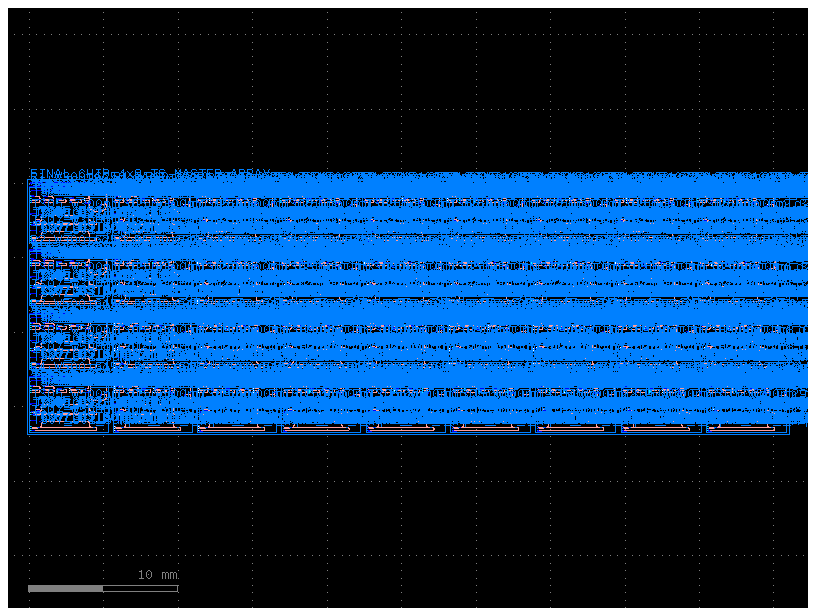

In [3]:
# %% [markdown]
# # Final chip: 4 × 9 array of organized TS master cells
#
# Rows:
#
# - Row 1: width = 300 nm, gap = 250 nm, fine length sweep around L50
# - Row 2: width = 300 nm, gap = 250 nm, beat-length sweep from L50 to L50 + 1.3 Lpi
# - Row 3: width = 500 nm, gap = 150 nm, fine length sweep around L50
# - Row 4: width = 500 nm, gap = 150 nm, beat-length sweep from L50 to L50 + 1.3 Lpi

# %%
from pathlib import Path
import numpy as np
import pandas as pd

# ============================================================
# Final-chip design inputs
# ============================================================
# Put your final designed 50/50 coupling lengths here.
# Units are um.

# 300 nm width / 250 nm gap
L50_w300_g250_um = 1.77
Lpi_w300_g250_um = 5.423

# 500 nm width / 150 nm gap
L50_w500_g150_um = 7.49
Lpi_w500_g150_um = 24.77

# Fine sweep:
# 4 points before L50, L50 itself, and 4 points after.
fine_step_um = 0.2

# Coarse sweep:
# From simulated L50 to 1.3 * Lpi using 8 points.
coarse_fraction_of_Lpi = 1.3
coarse_npoints = 9

# Final-chip placement settings.
chip_col_gap_um = 350.0
chip_row_gap_um = 500.0

chip_title_size_um = 90.0
chip_row_label_size_um = 45.0
chip_col_label_size_um = 30.0

chip_border_margin_um = 150.0
chip_border_line_width_um = 12.0

# Use LABEL_LAYER for the final chip border, consistent with the label/border convention.
chip_border_layer = LABEL_LAYER

# Output names.
FINAL_CHIP_NAME = "FINAL_CHIP_4x9_BS_ARRAY"
FINAL_CHIP_GDS = "final_chip_4x9_bs_array.gds"
FINAL_CHIP_CSV = "final_chip_4x9_bs_array_summary.csv"


# ============================================================
# Length-sweep helpers
# ============================================================

def make_fine_length_sweep_um(
    L50_um: float,
    step_um: float = 0.2,
    n_each_side: int = 4,
) -> np.ndarray:
    """
    Return 9 points:
        L50 + [-4, -3, -2, -1, 0, +1, +2, +3, +4] * step
    """
    offsets = np.arange(-n_each_side, n_each_side + 1, dtype=float)
    return L50_um + offsets * step_um


def make_coarse_length_sweep_um(
    L50_um: float,
    Lpi_um: float,
    fraction_of_Lpi: float = 1.3,
    npoints: int = 9,
) -> np.ndarray:
    """
    Return coarse sweep points from:
        L50
    to:
        fraction_of_Lpi * Lpi
    """
    return np.linspace(L50_um, fraction_of_Lpi * Lpi_um, npoints)


def get_component_or_ref_bounds_um(obj):
    """
    Compatibility wrapper for components and references.
    """
    try:
        return get_ref_bounds_um(obj)
    except Exception:
        pass

    try:
        return get_component_bounds_um(obj)
    except Exception:
        pass

    try:
        bbox = obj.bbox() if callable(obj.bbox) else obj.bbox
        bbox = np.array(bbox, dtype=float)
        xmin, ymin = bbox[0]
        xmax, ymax = bbox[1]
        return float(xmin), float(ymin), float(xmax), float(ymax)
    except Exception:
        pass

    try:
        dbbox = obj.dbbox() if callable(obj.dbbox) else obj.dbbox
        return float(dbbox.left), float(dbbox.bottom), float(dbbox.right), float(dbbox.top)
    except Exception:
        pass

    raise RuntimeError("Could not read bounds.")


def add_final_chip_label(
    c: gf.Component,
    text: str,
    position: tuple[float, float],
    size: float,
    text_layer: tuple[int, int] = TEXT_LAYER,
    label_layer: tuple[int, int] = LABEL_LAYER,
    add_gds_label: bool = False,
):
    """
    Add visible polygon text for final chip labels.
    """
    add_visible_text(
        c=c,
        text=text,
        position=position,
        size=size,
        text_layer=text_layer,
        label_layer=label_layer,
        add_gds_label=add_gds_label,
    )


# ============================================================
# Final 4 × 9 chip generator
# ============================================================

def make_final_chip_4x9_bs_array(
    name: str = FINAL_CHIP_NAME,
    L50_w300_g250_um: float = L50_w300_g250_um,
    Lpi_w300_g250_um: float = Lpi_w300_g250_um,
    L50_w500_g150_um: float = L50_w500_g150_um,
    Lpi_w500_g150_um: float = Lpi_w500_g150_um,
    fine_step_um: float = fine_step_um,
    coarse_fraction_of_Lpi: float = coarse_fraction_of_Lpi,
    coarse_npoints: int = coarse_npoints,
    col_gap_um: float = chip_col_gap_um,
    row_gap_um: float = chip_row_gap_um,
    title_size_um: float = chip_title_size_um,
    row_label_size_um: float = chip_row_label_size_um,
    col_label_size_um: float = chip_col_label_size_um,
    border_margin_um: float = chip_border_margin_um,
    border_line_width_um: float = chip_border_line_width_um,
    border_layer: tuple[int, int] = chip_border_layer,
    wg_layer: tuple[int, int] = WG_LAYER,
    text_layer: tuple[int, int] = TEXT_LAYER,
    label_layer: tuple[int, int] = LABEL_LAYER,
    add_labels: bool = True,
) -> tuple[gf.Component, pd.DataFrame]:

    final_chip = gf.Component(unique_cell_name(name))

    # --------------------------------------------------------
    # Length sweeps
    # --------------------------------------------------------
    fine_300 = make_fine_length_sweep_um(
        L50_um=L50_w300_g250_um,
        step_um=fine_step_um,
        n_each_side=4,
    )

    coarse_300 = make_coarse_length_sweep_um(
        L50_um=L50_w300_g250_um,
        Lpi_um=Lpi_w300_g250_um,
        fraction_of_Lpi=coarse_fraction_of_Lpi,
        npoints=coarse_npoints,
    )

    fine_500 = make_fine_length_sweep_um(
        L50_um=L50_w500_g150_um,
        step_um=fine_step_um,
        n_each_side=4,
    )

    coarse_500 = make_coarse_length_sweep_um(
        L50_um=L50_w500_g150_um,
        Lpi_um=Lpi_w500_g150_um,
        fraction_of_Lpi=coarse_fraction_of_Lpi,
        npoints=coarse_npoints,
    )

    row_specs = [
        {
            "row_index": 1,
            "row_id": "R1_W300_G250_FINE",
            "description": "W=300 nm, G=250 nm, fine sweep around L50",
            "width_um": 0.300,
            "gap_um": 0.250,
            "lengths_um": fine_300,
            "sweep_type": "fine_pm_0p2um",
            "L50_um": L50_w300_g250_um,
            "Lpi_um": Lpi_w300_g250_um,
        },
        {
            "row_index": 2,
            "row_id": "R2_W300_G250_BEAT",
            "description": "W=300 nm, G=250 nm, L50 to L50 + 1.3 Lpi",
            "width_um": 0.300,
            "gap_um": 0.250,
            "lengths_um": coarse_300,
            "sweep_type": "coarse_L50_to_1p3Lpi",
            "L50_um": L50_w300_g250_um,
            "Lpi_um": Lpi_w300_g250_um,
        },
        {
            "row_index": 3,
            "row_id": "R3_W500_G150_FINE",
            "description": "W=500 nm, G=150 nm, fine sweep around L50",
            "width_um": 0.500,
            "gap_um": 0.150,
            "lengths_um": fine_500,
            "sweep_type": "fine_pm_0p2um",
            "L50_um": L50_w500_g150_um,
            "Lpi_um": Lpi_w500_g150_um,
        },
        {
            "row_index": 4,
            "row_id": "R4_W500_G150_BEAT",
            "description": "W=500 nm, G=150 nm, L50 to L50 + 1.3 Lpi",
            "width_um": 0.500,
            "gap_um": 0.150,
            "lengths_um": coarse_500,
            "sweep_type": "coarse_L50_to_1p3Lpi",
            "L50_um": L50_w500_g150_um,
            "Lpi_um": Lpi_w500_g150_um,
        },
    ]

    # --------------------------------------------------------
    # Global final-chip title
    # --------------------------------------------------------
    if add_labels:
        add_final_chip_label(
            c=final_chip,
            text="FINAL CHIP | 4 x 9 BEAM-SPLITTER ARRAY | TS01-TS07 MASTER CELLS",
            position=(0.0, 0.0),
            size=title_size_um,
            text_layer=text_layer,
            label_layer=label_layer,
            add_gds_label=False,
        )

        final_chip.add_label(
            text="FINAL_CHIP_4x9_TS_MASTER_ARRAY",
            position=(0.0, -0.8 * title_size_um),
            layer=label_layer,
        )

    summary_rows = []

    # Start below the title.
    y_cursor = -2.5 * title_size_um

    # --------------------------------------------------------
    # Place rows
    # --------------------------------------------------------
    for row_spec in row_specs:
        x_cursor = 0.0

        row_top = None
        row_bottom = None
        row_left = None
        row_right = None

        if add_labels:
            row_label = (
                f"ROW {row_spec['row_index']} | {row_spec['description']} | "
                f"L50={row_spec['L50_um']:.3f} um | "
                f"Lpi={row_spec['Lpi_um']:.3f} um"
            )

            add_final_chip_label(
                c=final_chip,
                text=row_label,
                position=(x_cursor, y_cursor),
                size=row_label_size_um,
                text_layer=text_layer,
                label_layer=label_layer,
                add_gds_label=False,
            )

        # Device row starts below row label.
        device_y_target_top = y_cursor - 1.5 * row_label_size_um

        for col_index, Lc_um in enumerate(row_spec["lengths_um"], start=1):

            cell_name = (
                f"{row_spec['row_id']}_C{col_index:02d}_"
                f"w{int(row_spec['width_um'] * 1000)}nm_"
                f"g{int(row_spec['gap_um'] * 1000)}nm_"
                f"Lc{Lc_um:.3f}um"
            )

            ts_master = make_all_ts_organized_for_bs_settings(
                name=cell_name,
                bs_wg_width=row_spec["width_um"],
                bs_gap=row_spec["gap_um"],
                bs_coupling_length=float(Lc_um),
                wg_layer=wg_layer,
                text_layer=text_layer,
                label_layer=label_layer,
                add_labels=add_labels,
                border_layer=label_layer,
            )

            ref = final_chip << ts_master

            xmin, ymin, xmax, ymax = get_component_or_ref_bounds_um(ref)

            # Move so each cell's left edge is at x_cursor
            # and top edge is at device_y_target_top.
            ref.move((x_cursor - xmin, device_y_target_top - ymax))

            xmin, ymin, xmax, ymax = get_component_or_ref_bounds_um(ref)

            if add_labels:
                col_label = (
                    f"C{col_index:02d} | "
                    f"W={int(row_spec['width_um'] * 1000)} nm | "
                    f"G={int(row_spec['gap_um'] * 1000)} nm | "
                    f"Lc={Lc_um:.3f} um"
                )

                add_final_chip_label(
                    c=final_chip,
                    text=col_label,
                    position=(xmin, ymax + 25.0),
                    size=col_label_size_um,
                    text_layer=text_layer,
                    label_layer=label_layer,
                    add_gds_label=False,
                )

                final_chip.add_label(
                    text=(
                        f"{row_spec['row_id']}_C{col_index:02d}_"
                        f"w{int(row_spec['width_um'] * 1000)}nm_"
                        f"g{int(row_spec['gap_um'] * 1000)}nm_"
                        f"Lc{Lc_um:.3f}um"
                    ),
                    position=(xmin, ymax + 10.0),
                    layer=label_layer,
                )

            row_top = ymax if row_top is None else max(row_top, ymax)
            row_bottom = ymin if row_bottom is None else min(row_bottom, ymin)
            row_left = xmin if row_left is None else min(row_left, xmin)
            row_right = xmax if row_right is None else max(row_right, xmax)

            summary_rows.append(
                {
                    "row": row_spec["row_index"],
                    "column": col_index,
                    "row_id": row_spec["row_id"],
                    "sweep_type": row_spec["sweep_type"],
                    "width_um": row_spec["width_um"],
                    "width_nm": int(round(row_spec["width_um"] * 1000)),
                    "gap_um": row_spec["gap_um"],
                    "gap_nm": int(round(row_spec["gap_um"] * 1000)),
                    "L50_um": row_spec["L50_um"],
                    "Lpi_um": row_spec["Lpi_um"],
                    "coupling_length_um": float(Lc_um),
                    "delta_from_L50_um": float(Lc_um - row_spec["L50_um"]),
                    "cell_name": cell_name,
                }
            )

            # Next column.
            x_cursor = xmax + col_gap_um

        # Next row starts below the lowest geometry in this row.
        if row_bottom is None:
            raise RuntimeError("Row placement failed: no cells were placed.")

        y_cursor = row_bottom - row_gap_um

    # --------------------------------------------------------
    # Add chip border after everything is placed
    # --------------------------------------------------------
    xmin_all, ymin_all, xmax_all, ymax_all = get_component_or_ref_bounds_um(final_chip)

    add_square_border(
        c=final_chip,
        xmin=xmin_all,
        ymin=ymin_all,
        xmax=xmax_all,
        ymax=ymax_all,
        margin=border_margin_um,
        line_width=border_line_width_um,
        layer=border_layer,
    )

    # --------------------------------------------------------
    # Metadata
    # --------------------------------------------------------
    final_chip.info["description"] = "4x9 array of organized TS01-TS07 master cells"
    final_chip.info["rows"] = 4
    final_chip.info["columns"] = 9
    final_chip.info["num_master_cells"] = 36

    final_chip.info["row1"] = "width 300 nm, gap 250 nm, fine Lc sweep"
    final_chip.info["row2"] = "width 300 nm, gap 250 nm, beat Lc sweep"
    final_chip.info["row3"] = "width 500 nm, gap 150 nm, fine Lc sweep"
    final_chip.info["row4"] = "width 500 nm, gap 150 nm, beat Lc sweep"

    final_chip.info["L50_w300_g250_um"] = L50_w300_g250_um
    final_chip.info["Lpi_w300_g250_um"] = Lpi_w300_g250_um
    final_chip.info["L50_w500_g150_um"] = L50_w500_g150_um
    final_chip.info["Lpi_w500_g150_um"] = Lpi_w500_g150_um

    final_chip.info["fine_step_um"] = fine_step_um
    final_chip.info["coarse_fraction_of_Lpi"] = coarse_fraction_of_Lpi
    final_chip.info["coarse_npoints"] = coarse_npoints

    final_chip.info["text_layer"] = text_layer
    final_chip.info["label_layer"] = label_layer
    final_chip.info["border_layer"] = border_layer

    summary_df = pd.DataFrame(summary_rows)

    return final_chip, summary_df


# ============================================================
# Build, plot, and write the final chip
# ============================================================

final_chip, final_chip_summary = make_final_chip_4x9_bs_array(
    L50_w300_g250_um=L50_w300_g250_um,
    Lpi_w300_g250_um=Lpi_w300_g250_um,
    L50_w500_g150_um=L50_w500_g150_um,
    Lpi_w500_g150_um=Lpi_w500_g150_um,
    fine_step_um=fine_step_um,
    coarse_fraction_of_Lpi=coarse_fraction_of_Lpi,
    coarse_npoints=coarse_npoints,
    border_layer=LABEL_LAYER,
)

# Preview in notebook.
final_chip.plot()

# Write output GDS and summary CSV.
GDS_DIR = Path(GDS_DIR)
GDS_DIR.mkdir(parents=True, exist_ok=True)

final_chip_gds_path = GDS_DIR / FINAL_CHIP_GDS
final_chip.write_gds(final_chip_gds_path)

final_chip_csv_path = GDS_DIR / FINAL_CHIP_CSV
final_chip_summary.to_csv(final_chip_csv_path, index=False)

# Also write to DOE_GDS_DIR if it exists in your settings.
try:
    DOE_GDS_DIR = Path(DOE_GDS_DIR)
    DOE_GDS_DIR.mkdir(parents=True, exist_ok=True)

    final_chip_gds_path_doe = DOE_GDS_DIR / FINAL_CHIP_GDS
    final_chip.write_gds(final_chip_gds_path_doe)

    final_chip_csv_path_doe = DOE_GDS_DIR / FINAL_CHIP_CSV
    final_chip_summary.to_csv(final_chip_csv_path_doe, index=False)

except NameError:
    final_chip_gds_path_doe = None
    final_chip_csv_path_doe = None

print("Saved final chip GDS:")
print(final_chip_gds_path.resolve())

print("\nSaved final chip summary CSV:")
print(final_chip_csv_path.resolve())

if final_chip_gds_path_doe is not None:
    print("\nSaved DOE copy:")
    print(final_chip_gds_path_doe.resolve())
    print(final_chip_csv_path_doe.resolve())

print("\nFinal chip length table:")
display(final_chip_summary)